<a href="https://colab.research.google.com/github/Nachos-mic/Lung_CT_Diagnostic_ML/blob/main/Lung_Diagnostics_MASKED_SLICE_WCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioteki


In [1]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 152.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import WeightedRandomSampler
import optuna
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, accuracy_score
import random
import torch.nn.functional as F
import cv2
import json
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


MERGED_STAGE_TO_LABEL = {
    'I': 0,
    'II': 1,
    'IIIa': 2,
    'IIIb': 2,
    'III': 2,
}
LABEL_TO_MERGED_STAGE = {
    0: 'I',
    1: 'II',
    2: 'III',
}
NUM_CLASSES = len(LABEL_TO_MERGED_STAGE)


def merge_stage_label(value):
    if pd.isna(value):
        raise ValueError('Missing stage or label value')

    if isinstance(value, str):
        normalized = value.strip()
        if normalized in MERGED_STAGE_TO_LABEL:
            return MERGED_STAGE_TO_LABEL[normalized]
        return 2 if normalized == 'III' else int(normalized)

    return 2 if int(value) == 3 else int(value)


Rozpakowanie danych do dysku (jednorazowe)

In [7]:
import zipfile
import os

from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/content/dataset_masked', exist_ok=True)

with zipfile.ZipFile('/content/drive/MyDrive/masked_lung_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_masked')

print("Gotowe!")
print(os.listdir('/content/dataset_masked'))

Mounted at /content/drive
Gotowe!
['data_2d_masked_ct', 'master_dataset.csv', 'train.csv', 'test.csv', 'val.csv', 'NSCLC-Radiomics-Lung1.clinical-data.csv']


In [5]:
!ls "/content/drive/MyDrive/" | grep masked

ls: cannot access '/content/drive/MyDrive/': No such file or directory


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_7424/44401997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')


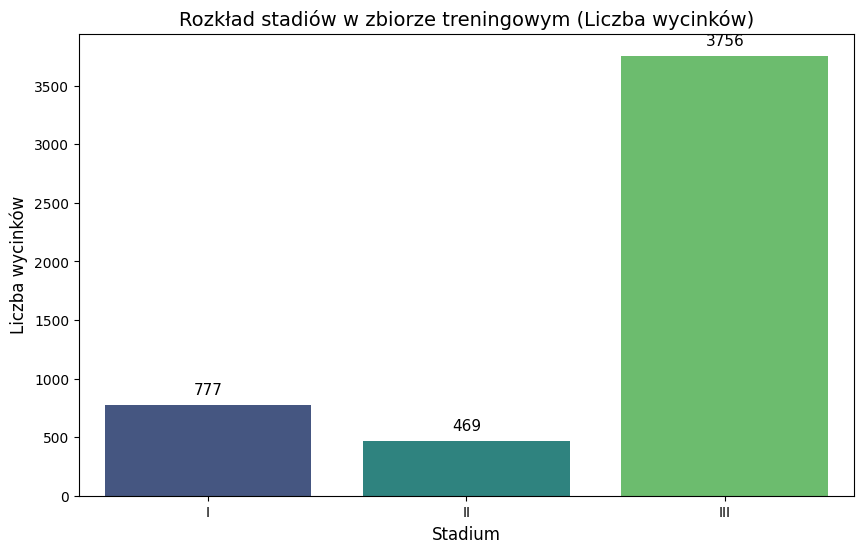


--- Przykładowe wycinki dla poszczególnych klas ---


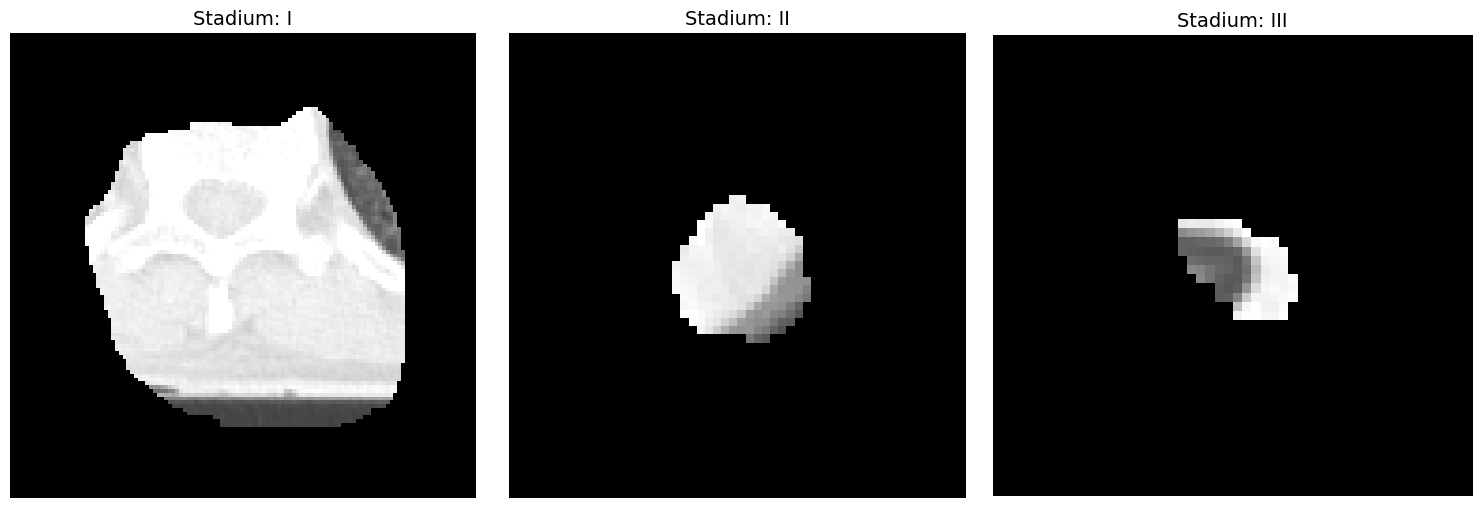

In [8]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset_masked/train.csv'

df_train = pd.read_csv(TRAIN_CSV)
df_train['merged_stage'] = df_train['original_stage'].replace({'IIIa': 'III', 'IIIb': 'III'})

# Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Wizualizacja przykładowych zdjęć dla każdej z 3 klas po połączeniu IIIa i IIIb
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stages = ['I', 'II', 'III']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['merged_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset_masked/data_2d_masked_ct', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

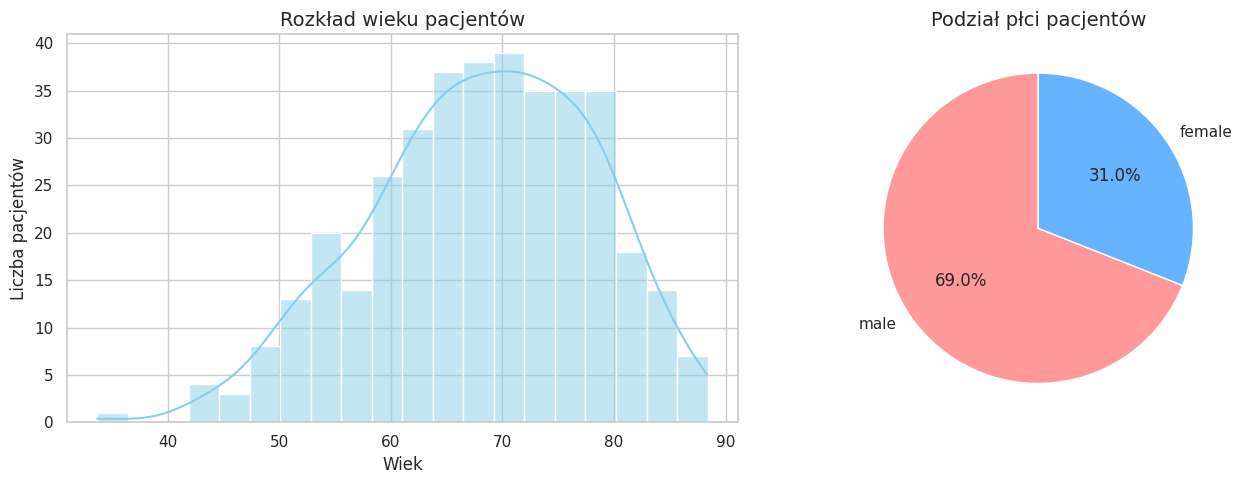

/tmp/ipykernel_7424/624192595.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


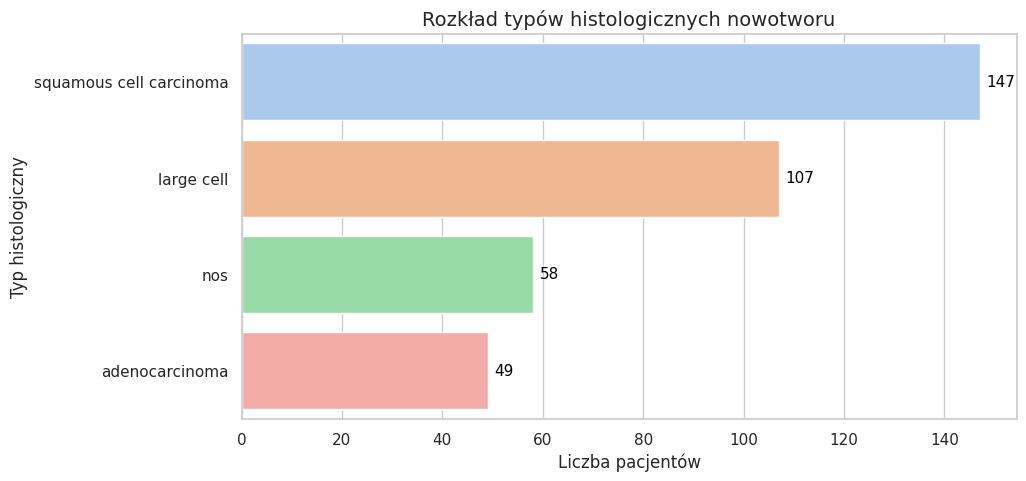

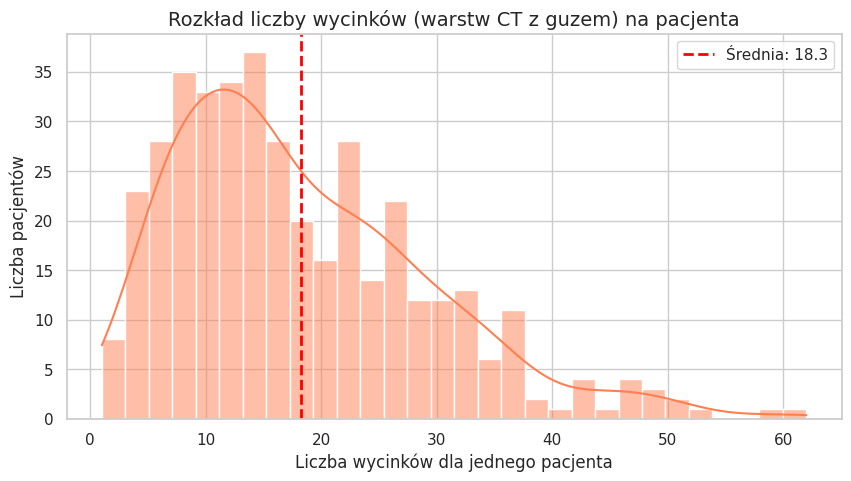

Całkowita liczba uwzględnionych pacjentów: 400
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 18.3
Pacjent z najmniejszą liczbą wycinków ma ich: 1
Pacjent z największą liczbą wycinków ma ich: 62


In [9]:

MASTER_CSV = r"/content/dataset_masked/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset_masked/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

# PROTO - dodanie wieku i innych cech:



In [10]:
# Wczytanie i przygotowanie metadanych klinicznych
df_clinical = pd.read_csv('/content/dataset_masked/NSCLC-Radiomics-Lung1.clinical-data.csv')

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()

# Wczytanie pacjentów tylko ze zbioru treningowego
df_train_for_leak = pd.read_csv('/content/dataset_masked/train.csv')
train_patient_ids = df_train_for_leak['patient_id'].astype(str).str.strip().unique()

train_clinical = df_clinical[df_clinical['PatientID'].isin(train_patient_ids)]
age_mean = train_clinical['age'].mean()
age_std = train_clinical['age'].std()

# Aplikacja normalizacji na WSZYSTKICH pacjentów (Train, Val, Test) używając parametrów treningowych
df_clinical['age_norm'] = (df_clinical['age'] - age_mean) / age_std

df_clinical['gender_bin'] = df_clinical['gender'].map({'male': 0.0, 'female': 1.0}).fillna(0.0)
clinical_features = df_clinical[['PatientID', 'age_norm', 'gender_bin']]

Preprocessing do ResNet

In [11]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),  # nowe
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08)),  # lżejszy niż przy full slices
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms dla masked CT gotowe!")

Transforms dla masked CT gotowe!


Klasa Dataset

In [12]:
class LungCancerHybridDataset(Dataset):
    def __init__(self, csv_file, clinical_df, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Merge z danymi klinicznymi
        self.data_frame = self.data_frame.merge(
            clinical_df[['PatientID', 'age_norm', 'gender_bin']],
            left_on='patient_id', right_on='PatientID', how='left'
        )

        self.data_frame['age_norm'] = self.data_frame['age_norm'].fillna(0.0)
        self.data_frame['gender_bin'] = self.data_frame['gender_bin'].fillna(0.0)

        # Mapowanie etykiet
        label_col = 'original_stage' if 'original_stage' in self.data_frame.columns else 'label'
        self.data_frame['merged_label'] = self.data_frame[label_col].apply(merge_stage_label)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]

        # Obraz
        filename = os.path.basename(row['image_path'].replace('\\', '/'))
        img_path = os.path.join(self.root_dir, filename)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Dane kliniczne (Wiek, Płeć)
        clinical_vec = torch.tensor([row['age_norm'], row['gender_bin']], dtype=torch.float32)

        # Etykieta
        label = int(row['merged_label'])

        return image, clinical_vec, label



DataLoaders i WeightedSampler


In [13]:
from posix import truncate
from sklearn.utils.class_weight import compute_class_weight
IMG_DIR_COLAB = '/content/dataset_masked/data_2d_masked_ct'

# Tworzenie instancji hybrydowych datasetów
train_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/train.csv',
                                        clinical_df=clinical_features,
                                        root_dir=IMG_DIR_COLAB,
                                        transform=train_transforms)

val_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/val.csv',
                                      clinical_df=clinical_features,
                                      root_dir=IMG_DIR_COLAB,
                                      transform=val_test_transforms)

test_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/test.csv',
                                       clinical_df=clinical_features,
                                       root_dir=IMG_DIR_COLAB,
                                       transform=val_test_transforms)

# Weighted Sampler - Balansowanie klas I, II, III
train_labels = train_dataset.data_frame['merged_label'].values
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = torch.from_numpy(class_weights[train_labels]).type(torch.DoubleTensor)

CT_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# OBLICZENIE WAG DLA FUNKCJI STRATY
# Używamy dokładnie tej nazwy kolumny, którą miałeś w samplerze: 'merged_label'
train_labels_for_loss = train_dataset.data_frame['merged_label'].values

computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_for_loss),
    y=train_labels_for_loss
)

print(f"\nWyliczone wagi klas dla Loss Function (I, II, III): {computed_weights}")

# Weryfikacja
sample_batch = next(iter(train_loader))
print(f"Batch obrazów: {sample_batch[0].shape}")
print(f"Batch danych klinicznych: {sample_batch[1].shape}") # Powinno być [32, 2]
print(f"Batch etykiet: {sample_batch[2].shape}")
print("\nDane gotowe do treningu hybrydowego!")


Wyliczone wagi klas dla Loss Function (I, II, III): [2.14586015 3.55508173 0.44391196]
Batch obrazów: torch.Size([32, 3, 224, 224])
Batch danych klinicznych: torch.Size([32, 2])
Batch etykiet: torch.Size([32])

Dane gotowe do treningu hybrydowego!


In [19]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

Trening ResNet- 18

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

class ResNetHybrid(nn.Module):
    def __init__(self, num_classes=3, hidden_units=512, dropout_rate=0.4):
        super(ResNetHybrid, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs + 2, hidden_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_units, num_classes)
        )

    def forward(self, img, clinical):
        img_features = self.backbone(img)
        combined     = torch.cat((img_features, clinical), dim=1)
        return self.classifier(combined)

model = ResNetHybrid(num_classes=3, dropout_rate=0.4)

for param in model.parameters():
    param.requires_grad = False
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

train_labels  = train_dataset.data_frame['merged_label'].values
class_counts  = np.bincount(train_labels)
soft_weights  = 1.0 / np.sqrt(class_counts)
soft_weights  = soft_weights / soft_weights.sum() * 3
weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
    {'params': model.backbone.layer4.parameters(), 'lr': 5e-6},
    {'params': model.classifier.parameters(),      'lr': 1e-3}
], weight_decay=1e-3)

print("Setup: Baseline CrossEntropy gotowy!")

Używane urządzenie: cuda
Setup: Baseline CrossEntropy gotowy!


Pętla ucząca

Epoka 1/20
TRAIN Loss: 0.9912 | Acc: 0.6883 | F1: 0.4010 | AUC: 0.6050
VAL Loss: 0.7954 | Acc: 0.6909 | F1: 0.3638 | AUC: 0.7339
*** Nowy rekord AUC: 0.7339 ***
*** Zapisano model (Nowy rekord F1: 0.3638) ***

Epoka 2/20
TRAIN Loss: 0.8892 | Acc: 0.7487 | F1: 0.4981 | AUC: 0.6991
VAL Loss: 0.7876 | Acc: 0.7011 | F1: 0.4869 | AUC: 0.7549
*** Nowy rekord AUC: 0.7549 ***
*** Zapisano model (Nowy rekord F1: 0.4869) ***

Epoka 3/20
TRAIN Loss: 0.8425 | Acc: 0.7513 | F1: 0.5279 | AUC: 0.7385
VAL Loss: 0.7367 | Acc: 0.7267 | F1: 0.4810 | AUC: 0.7625
*** Nowy rekord AUC: 0.7625 ***

Epoka 4/20
TRAIN Loss: 0.8268 | Acc: 0.7609 | F1: 0.5396 | AUC: 0.7529
VAL Loss: 0.7701 | Acc: 0.7370 | F1: 0.4436 | AUC: 0.7510

Epoka 5/20
TRAIN Loss: 0.8205 | Acc: 0.7647 | F1: 0.5565 | AUC: 0.7511
VAL Loss: 0.7875 | Acc: 0.7054 | F1: 0.5110 | AUC: 0.7458
*** Zapisano model (Nowy rekord F1: 0.5110) ***

Epoka 6/20
TRAIN Loss: 0.8127 | Acc: 0.7625 | F1: 0.5565 | AUC: 0.7542
VAL Loss: 0.7822 | Acc: 0.7105 | F1: 0.

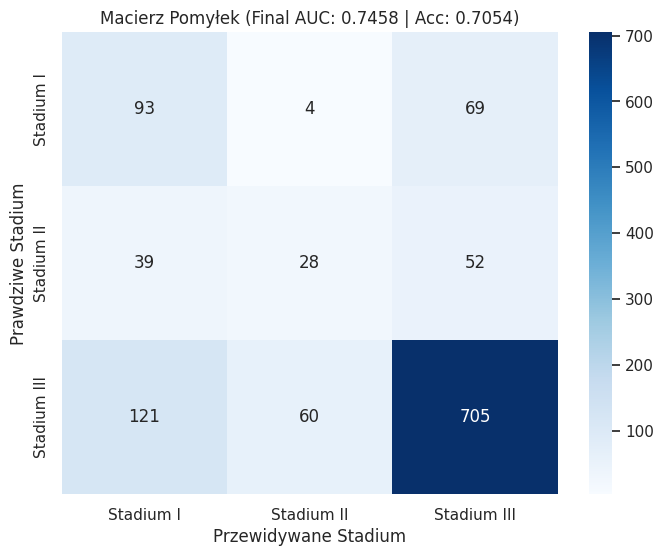

 Wyniki soft-voting na zbiorze walidacyjnym
 (Agregacja 2D -> 3D za pomocą Soft Voting)
PATIENT AUC: 0.7775 (Wynik referencyjny z publikacji: 0.881)
PATIENT ACC: 0.7500
              precision    recall  f1-score   support

   Stadium I       0.62      0.62      0.62        13
  Stadium II       0.50      0.33      0.40         6
 Stadium III       0.81      0.85      0.83        41

    accuracy                           0.75        60
   macro avg       0.64      0.60      0.62        60
weighted avg       0.74      0.75      0.74        60



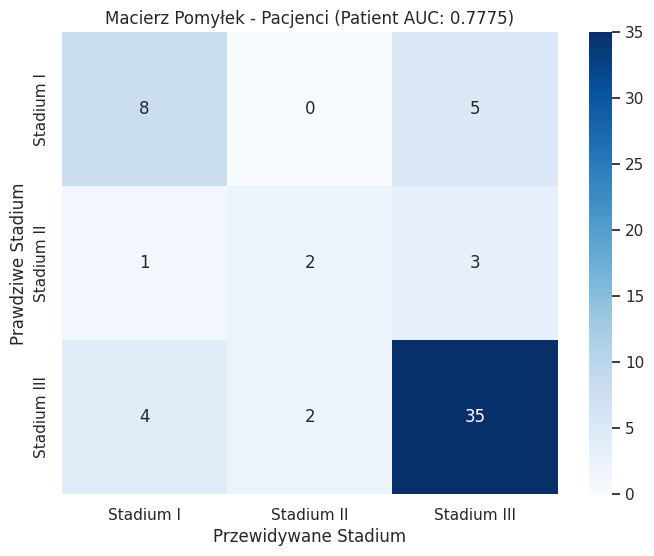

In [58]:
# konfiguracja treninigu
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
best_auc = 0.0
best_f1 = 0.0
best_acc = 0.0
results_path = 'best_metrics.txt'

with open(results_path, 'w') as f:
    f.write("REKORDY MODELU HYBRYDOWEGO (NSCLC STAGING)\n")


history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_auc': [], 'val_auc': []
}

NUM_EPOCHS = 20

# --- KONFIGURACJA EARLY STOPPING ---
patience = 10
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'Epoka {epoch+1}/{NUM_EPOCHS}')

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader

        running_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []

        for inputs, clinical_data, labels in dataloader:
            inputs, clinical_data, labels = inputs.to(device), clinical_data.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs, clinical_data)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            epoch_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            epoch_auc = 0.0

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        history[f'{phase}_f1'].append(epoch_f1)
        history[f'{phase}_auc'].append(epoch_auc)

        print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f} | AUC: {epoch_auc:.4f}')

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc

            # Rejestrowanie rekordu AUC (bez zapisu modelu)
            if epoch_auc > best_auc:
                best_auc = epoch_auc
                print(f"*** Nowy rekord AUC: {best_auc:.4f} ***")

            # Zapis modelu i Early Stopping na podstawie F1
            if epoch_f1 > best_f1:
                best_f1 = epoch_f1
                torch.save(model.state_dict(), 'best_hybrid_f1.pth')
                print(f"*** Zapisano model (Nowy rekord F1: {best_f1:.4f}) ***")
                epochs_no_improve = 0  # Resetujemy licznik cierpliwości
            else:
                epochs_no_improve += 1

    # Sprawdzenie warunku Early Stopping po zakończeniu obu faz (train i val) w epoce
    if epochs_no_improve >= patience:
        print(f"\n[Early Stopping] Brak poprawy F1 od {patience} epok. Przerwano trening.")
        break

    print()

# Ewaluacja
print("\nRaport klasyfikacji")

# WAŻNE: Wczytujemy model zapisany na podstawie najlepszego wyniku F1
model.load_state_dict(torch.load('best_hybrid_f1.pth'))
model.eval()

final_preds, final_labels, final_probs = [], [], []

with torch.no_grad():
    for inputs, clinical_data, labels in val_loader:
        inputs, clinical_data = inputs.to(device), clinical_data.to(device)
        outputs = model(inputs, clinical_data)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())
        final_probs.extend(probs.cpu().numpy())

final_auc = roc_auc_score(final_labels, final_probs, multi_class='ovr', average='macro')
final_acc = accuracy_score(final_labels, final_preds)

print(f"\nOstateczny wynik AUC: {final_auc:.4f}")
print(f"Ostateczny wynik Acc: {final_acc:.4f}")
print(f"Referencyjny wynik z publikacji (RF): 0.881")
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(final_labels, final_preds, target_names=target_names))

cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek (Final AUC: {final_auc:.4f} | Acc: {final_acc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

# Soft-voting na poziomie pacjentów

df_val_results = val_dataset.data_frame.copy()

df_val_results['prob_I'] = [p[0] for p in final_probs]
df_val_results['prob_II'] = [p[1] for p in final_probs]
df_val_results['prob_III'] = [p[2] for p in final_probs]
df_val_results['true_label'] = final_labels

patient_level_df = df_val_results.groupby('patient_id').agg({
    'prob_I': 'mean',
    'prob_II': 'mean',
    'prob_III': 'mean',
    'true_label': 'first'
}).reset_index()

patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds = np.argmax(patient_probs, axis=1)
patient_true = patient_level_df['true_label'].values

patient_acc = accuracy_score(patient_true, patient_preds)
patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')

print(" Wyniki soft-voting na zbiorze walidacyjnym")
print(" (Agregacja 2D -> 3D za pomocą Soft Voting)")
print(f"PATIENT AUC: {patient_auc:.4f} (Wynik referencyjny z publikacji: 0.881)")
print(f"PATIENT ACC: {patient_acc:.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek - Pacjenci (Patient AUC: {patient_auc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

Krzywa uczenia i straty

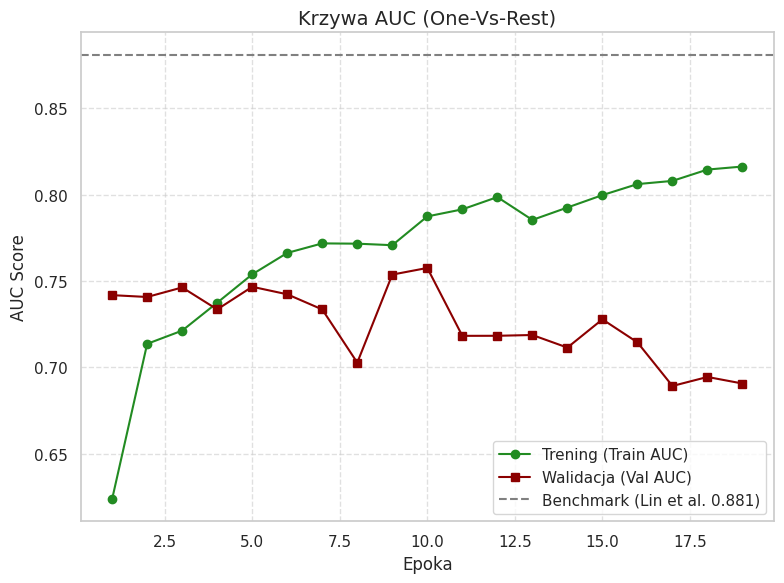

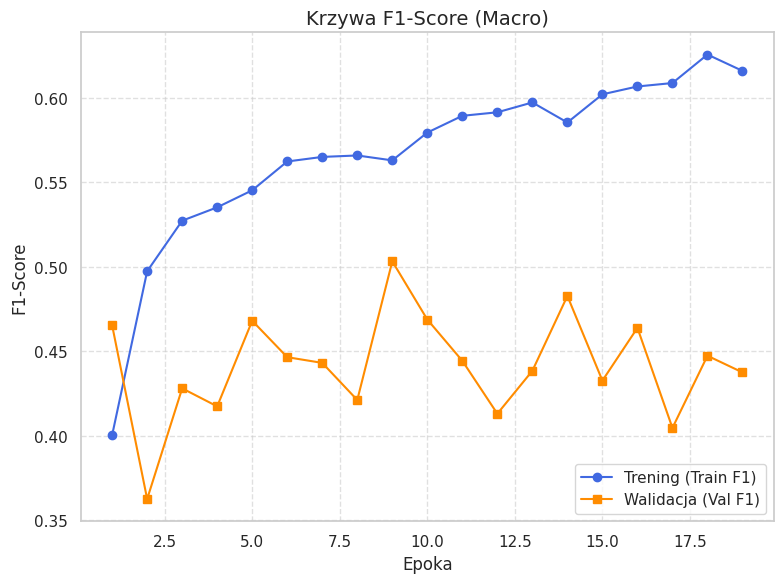

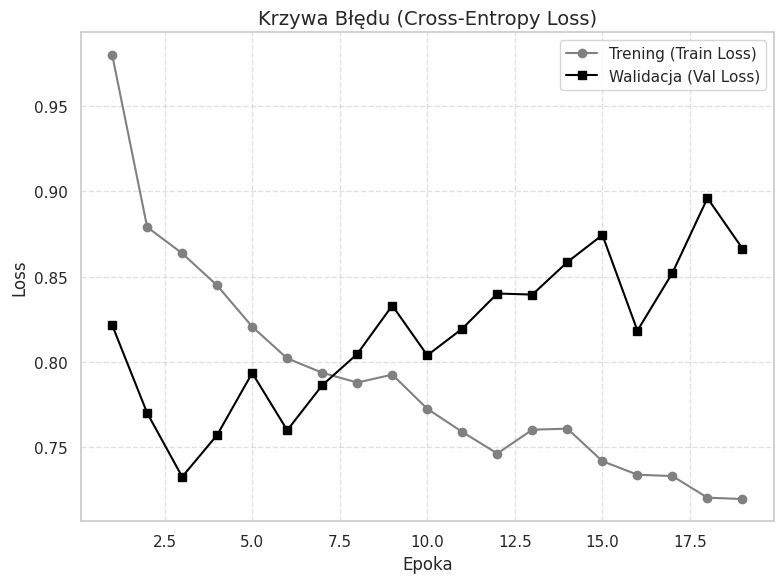

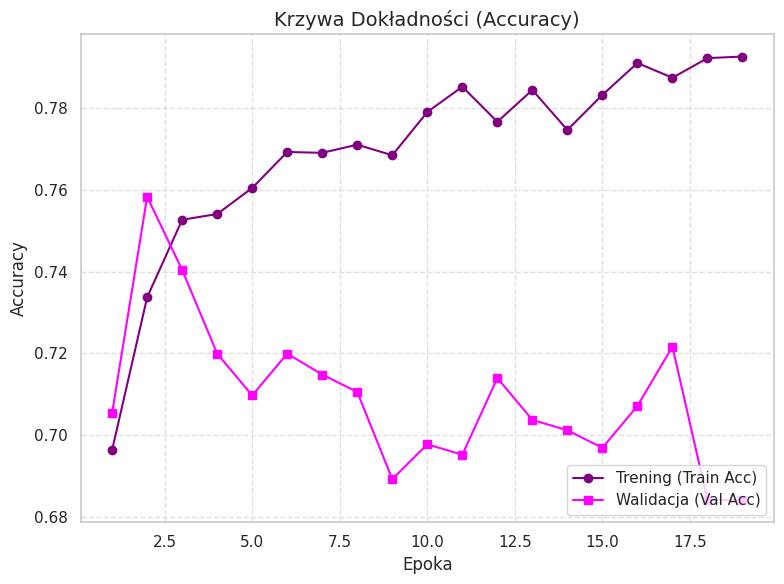

In [63]:
epochs_range = range(1, len(history['train_f1']) + 1)

#  AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_auc', [0]*len(epochs_range)), label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history.get('val_auc', [0]*len(epochs_range)), label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC (One-Vs-Rest)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_auc.png', dpi=300, bbox_inches='tight')
plt.show()


# F1-Score (Macro Average)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# Funkcja błędu (Loss)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_loss', [0]*len(epochs_range)), label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history.get('val_loss', [0]*len(epochs_range)), label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu (Cross-Entropy Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy (Dokładność)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_acc', [0]*len(epochs_range)), label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history.get('val_acc', [0]*len(epochs_range)), label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Grad-Cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


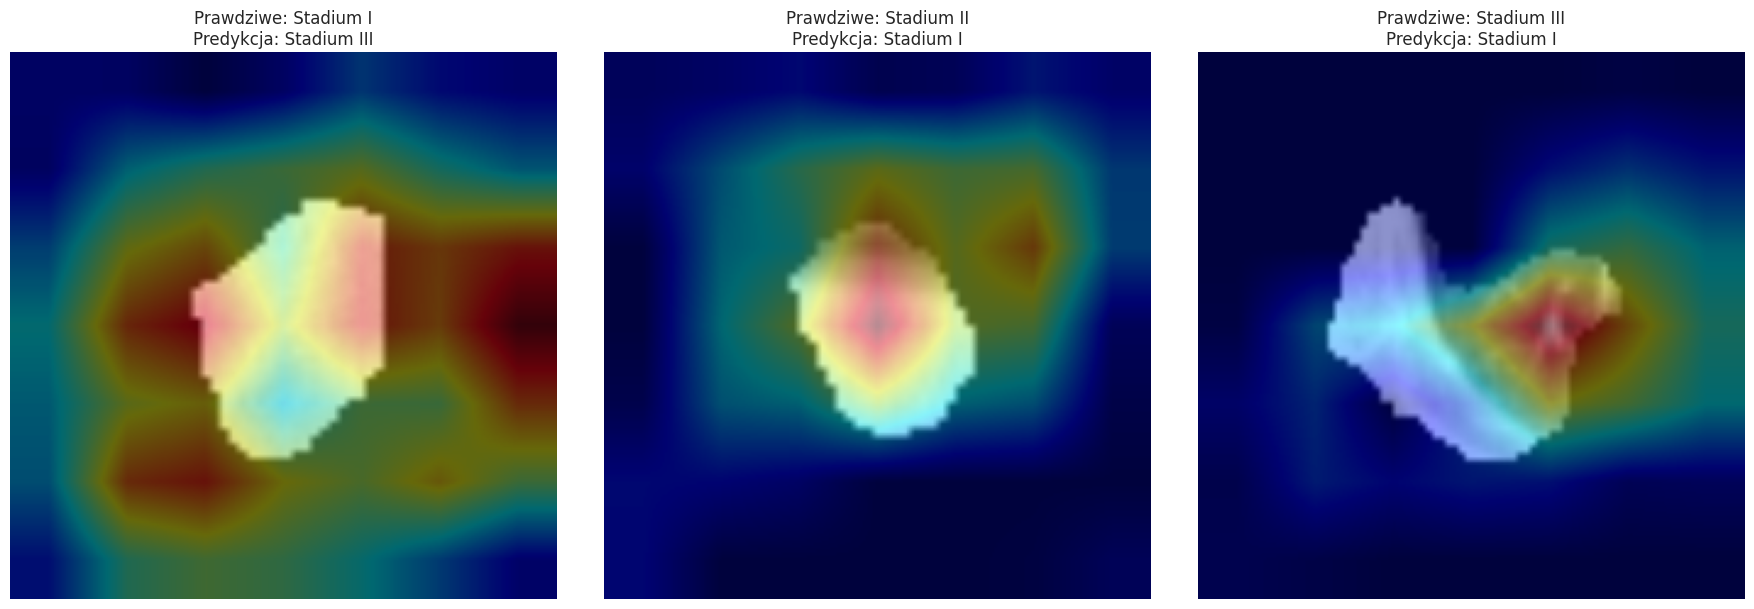

In [60]:
def generate_gradcam(model, input_img, clinical_data, target_layer):
    model.eval()

    feature_blobs = []
    gradients = []

    def hook_feature(module, input, output):
        feature_blobs.append(output.cpu().data.numpy())

    def hook_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0].cpu().data.numpy())

    handle_forward = target_layer.register_forward_hook(hook_feature)
    handle_backward = target_layer.register_backward_hook(hook_gradient)

    output = model(input_img, clinical_data)
    _, target_class = torch.max(output, 1)

    model.zero_grad()
    output[0, target_class].backward()

    # Wyznaczanie wag i mapy ciepła
    grads = gradients[0]
    weights = np.mean(grads, axis=(2, 3))[0]
    features = feature_blobs[0][0]

    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

    handle_forward.remove()
    handle_backward.remove()

    return cam, target_class.item()

def show_gradcam_gallery(model, dataset):
    # Szukamy po jednym przykładzie dla każdego stadium (0, 1, 2)
    indices = []
    for target_label in [0, 1, 2]:
        for i in range(len(dataset)):
            _, _, label = dataset[i]
            if label == target_label:
                indices.append(i)
                break

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    target_names = ['Stadium I', 'Stadium II', 'Stadium III']

    for i, idx in enumerate(indices):
        img_tensor, clinical_tensor, label = dataset[idx]

        input_img = img_tensor.unsqueeze(0).to(device)
        clinical_data = clinical_tensor.unsqueeze(0).to(device)

        heatmap, pred_class = generate_gradcam(model, input_img, clinical_data, model.backbone.layer4)

        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_show + 0.4 * heatmap_color

        axes[i].imshow(overlay)
        axes[i].set_title(f"Prawdziwe: {target_names[label]}\nPredykcja: {target_names[pred_class]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Wywołanie
show_gradcam_gallery(model, val_dataset)

# Optuna


Tutaj celujemy w usprawnienie F1 jako metryki dla slice'ów

In [15]:
def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | F1: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open('/content/drive/MyDrive/best_optuna_params_masked.json', 'w') as fp:
            json.dump(study.best_params, fp)

In [17]:
EPOCHS_PER_TRIAL = 20

def objective(trial):
    lr_fc        = trial.suggest_float("lr_fc",        8e-4,  2e-3,  log=True)
    lr_layer4    = trial.suggest_float("lr_layer4",    3e-6,  2e-5,  log=True)
    lr_layer3    = trial.suggest_float("lr_layer3",    5e-7,  8e-6,  log=True)
    weight_decay = trial.suggest_float("weight_decay", 5e-4,  5e-3,  log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.30,  0.50)

    model = ResNetHybrid(num_classes=3, dropout_rate=dropout_rate).to(device)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.layer3.parameters():
        param.requires_grad = True
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    train_labels  = train_dataset.data_frame['merged_label'].values
    class_counts  = np.bincount(train_labels)
    soft_weights  = 1.0 / np.sqrt(class_counts)
    soft_weights  = soft_weights / soft_weights.sum() * 3
    weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    optimizer = optim.Adam([
        {'params': model.backbone.layer3.parameters(), 'lr': lr_layer3},
        {'params': model.backbone.layer4.parameters(), 'lr': lr_layer4},
        {'params': model.classifier.parameters(),      'lr': lr_fc}
    ], weight_decay=weight_decay)

    best_trial_auc = 0.0

    for epoch in range(EPOCHS_PER_TRIAL):
        model.train()
        for inputs, clinical_data, labels in train_loader:
            inputs        = inputs.to(device)
            clinical_data = clinical_data.to(device)
            labels        = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, clinical_data)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, clinical_data, labels in val_loader:
                inputs        = inputs.to(device)
                clinical_data = clinical_data.to(device)

                outputs = model(inputs, clinical_data)
                probs   = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')

        try:
            val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            val_auc = 0.0

        if val_auc > best_trial_auc:
            best_trial_auc = val_auc

        print(f"  Trial {trial.number} | E{epoch+1:02} | F1: {val_f1:.4f} | AUC: {val_auc:.4f} | Best AUC: {best_trial_auc:.4f}")

        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_trial_auc

def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | F1: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open('/content/drive/MyDrive/best_optuna_params_masked_auc_v1.json', 'w') as fp:
            json.dump(study.best_params, fp, indent=2)

# Nowe study dla masked CT
study = optuna.create_study(
    direction="maximize",
    study_name="ResNetHybrid_Masked_WCE_auc_V1",
    storage="sqlite:////content/drive/MyDrive/optuna_masked_wce_auc_v1.db",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

print(f"Triali w bazie: {len(study.trials)}")

study.optimize(
    objective,
    n_trials=30,
    timeout=36000,
    callbacks=[save_callback]
)

print(f"\nNajlepszy F1: {study.best_value:.4f}")
print("Najlepsze parametry:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

with open('/content/drive/MyDrive/best_optuna_params_masked_v1.json', 'w') as fp:
    json.dump(study.best_params, fp, indent=2)
print("\nParametry zapisane do Drive.")

[I 2026-04-25 19:31:31,380] A new study created in RDB with name: ResNetHybrid_Masked_WCE_auc_V1


Triali w bazie: 0
  Trial 0 | E01 | F1: 0.4911 | AUC: 0.7593 | Best AUC: 0.7593
  Trial 0 | E02 | F1: 0.4873 | AUC: 0.7207 | Best AUC: 0.7593
  Trial 0 | E03 | F1: 0.3879 | AUC: 0.7135 | Best AUC: 0.7593
  Trial 0 | E04 | F1: 0.4106 | AUC: 0.7358 | Best AUC: 0.7593
  Trial 0 | E05 | F1: 0.4270 | AUC: 0.7152 | Best AUC: 0.7593
  Trial 0 | E06 | F1: 0.4437 | AUC: 0.7450 | Best AUC: 0.7593
  Trial 0 | E07 | F1: 0.4227 | AUC: 0.7109 | Best AUC: 0.7593
  Trial 0 | E08 | F1: 0.4330 | AUC: 0.6902 | Best AUC: 0.7593
  Trial 0 | E09 | F1: 0.4246 | AUC: 0.7004 | Best AUC: 0.7593
  Trial 0 | E10 | F1: 0.4463 | AUC: 0.6999 | Best AUC: 0.7593
  Trial 0 | E11 | F1: 0.4322 | AUC: 0.6958 | Best AUC: 0.7593
  Trial 0 | E12 | F1: 0.4074 | AUC: 0.6529 | Best AUC: 0.7593
  Trial 0 | E13 | F1: 0.4565 | AUC: 0.6696 | Best AUC: 0.7593
  Trial 0 | E14 | F1: 0.4277 | AUC: 0.6651 | Best AUC: 0.7593
  Trial 0 | E15 | F1: 0.3604 | AUC: 0.6404 | Best AUC: 0.7593
  Trial 0 | E16 | F1: 0.4110 | AUC: 0.6566 | Best AU

[I 2026-04-25 19:38:22,592] Trial 0 finished with value: 0.7593218699611062 and parameters: {'lr_fc': 0.0015302003440149543, 'lr_layer4': 1.1590288142337804e-05, 'lr_layer3': 1.623963034237963e-06, 'weight_decay': 0.0036138803630796712, 'dropout_rate': 0.3420834036822406}. Best is trial 0 with value: 0.7593218699611062.


  Trial 0 | E20 | F1: 0.4124 | AUC: 0.6264 | Best AUC: 0.7593

✓ Trial 0 | F1: 0.7593 | Najlepszy: 0.7593
  Trial 1 | E01 | F1: 0.4136 | AUC: 0.7173 | Best AUC: 0.7173
  Trial 1 | E02 | F1: 0.4711 | AUC: 0.7434 | Best AUC: 0.7434
  Trial 1 | E03 | F1: 0.5061 | AUC: 0.7140 | Best AUC: 0.7434
  Trial 1 | E04 | F1: 0.4750 | AUC: 0.7184 | Best AUC: 0.7434
  Trial 1 | E05 | F1: 0.5046 | AUC: 0.7137 | Best AUC: 0.7434
  Trial 1 | E06 | F1: 0.4596 | AUC: 0.7153 | Best AUC: 0.7434
  Trial 1 | E07 | F1: 0.4248 | AUC: 0.7100 | Best AUC: 0.7434
  Trial 1 | E08 | F1: 0.4815 | AUC: 0.7167 | Best AUC: 0.7434
  Trial 1 | E09 | F1: 0.4488 | AUC: 0.7052 | Best AUC: 0.7434
  Trial 1 | E10 | F1: 0.4795 | AUC: 0.6976 | Best AUC: 0.7434
  Trial 1 | E11 | F1: 0.4637 | AUC: 0.6768 | Best AUC: 0.7434
  Trial 1 | E12 | F1: 0.4782 | AUC: 0.7041 | Best AUC: 0.7434
  Trial 1 | E13 | F1: 0.3987 | AUC: 0.6782 | Best AUC: 0.7434
  Trial 1 | E14 | F1: 0.4098 | AUC: 0.6753 | Best AUC: 0.7434
  Trial 1 | E15 | F1: 0.45

[I 2026-04-25 19:45:05,166] Trial 1 finished with value: 0.7433889757823309 and parameters: {'lr_fc': 0.000966587924390784, 'lr_layer4': 7.614268794385878e-06, 'lr_layer3': 4.640995632803401e-06, 'weight_decay': 0.0015762853270625751, 'dropout_rate': 0.3347533028226704}. Best is trial 0 with value: 0.7593218699611062.


...

  Trial 27 | E20 | F1: 0.4250 | AUC: 0.6655 | Best AUC: 0.7686

✓ Trial 27 | F1: 0.7686 | Najlepszy: 0.7686
  Trial 28 | E01 | F1: 0.3616 | AUC: 0.7622 | Best AUC: 0.7622
  Trial 28 | E02 | F1: 0.4056 | AUC: 0.7546 | Best AUC: 0.7622
  Trial 28 | E03 | F1: 0.4306 | AUC: 0.7378 | Best AUC: 0.7622
  Trial 28 | E04 | F1: 0.4586 | AUC: 0.7431 | Best AUC: 0.7622
  Trial 28 | E05 | F1: 0.4656 | AUC: 0.7156 | Best AUC: 0.7622
  Trial 28 | E06 | F1: 0.4547 | AUC: 0.7072 | Best AUC: 0.7622
  Trial 28 | E07 | F1: 0.4764 | AUC: 0.7257 | Best AUC: 0.7622
  Trial 28 | E08 | F1: 0.4482 | AUC: 0.7431 | Best AUC: 0.7622
  Trial 28 | E09 | F1: 0.4418 | AUC: 0.7152 | Best AUC: 0.7622
  Trial 28 | E10 | F1: 0.4016 | AUC: 0.6997 | Best AUC: 0.7622
  Trial 28 | E11 | F1: 0.4629 | AUC: 0.7019 | Best AUC: 0.7622
  Trial 28 | E12 | F1: 0.4192 | AUC: 0.7211 | Best AUC: 0.7622
  Trial 28 | E13 | F1: 0.4758 | AUC: 0.7025 | Best AUC: 0.7622
  Trial 28 | E14 | F1: 0.4664 | AUC: 0.7179 | Best AUC: 0.7622
  Trial 28

[I 2026-04-25 22:43:56,976] Trial 28 finished with value: 0.7621720940082577 and parameters: {'lr_fc': 0.001505515649676777, 'lr_layer4': 6.574316537993981e-06, 'lr_layer3': 1.9406401444297206e-06, 'weight_decay': 0.0036992607550803327, 'dropout_rate': 0.40261641786233815}. Best is trial 27 with value: 0.768585757794526.


  Trial 28 | E20 | F1: 0.4377 | AUC: 0.6748 | Best AUC: 0.7622

✓ Trial 28 | F1: 0.7622 | Najlepszy: 0.7686
  Trial 29 | E01 | F1: 0.3852 | AUC: 0.7317 | Best AUC: 0.7317
  Trial 29 | E02 | F1: 0.4424 | AUC: 0.7517 | Best AUC: 0.7517
  Trial 29 | E03 | F1: 0.3460 | AUC: 0.7269 | Best AUC: 0.7517
  Trial 29 | E04 | F1: 0.4748 | AUC: 0.7443 | Best AUC: 0.7517
  Trial 29 | E05 | F1: 0.3493 | AUC: 0.7143 | Best AUC: 0.7517
  Trial 29 | E06 | F1: 0.4704 | AUC: 0.7278 | Best AUC: 0.7517
  Trial 29 | E07 | F1: 0.3709 | AUC: 0.6891 | Best AUC: 0.7517
  Trial 29 | E08 | F1: 0.4441 | AUC: 0.7247 | Best AUC: 0.7517
  Trial 29 | E09 | F1: 0.4235 | AUC: 0.7125 | Best AUC: 0.7517
  Trial 29 | E10 | F1: 0.3901 | AUC: 0.6807 | Best AUC: 0.7517
  Trial 29 | E11 | F1: 0.4700 | AUC: 0.7209 | Best AUC: 0.7517
  Trial 29 | E12 | F1: 0.4736 | AUC: 0.7190 | Best AUC: 0.7517
  Trial 29 | E13 | F1: 0.3911 | AUC: 0.6892 | Best AUC: 0.7517
  Trial 29 | E14 | F1: 0.4536 | AUC: 0.6753 | Best AUC: 0.7517
  Trial 29

[I 2026-04-25 22:50:23,525] Trial 29 finished with value: 0.7516750711413422 and parameters: {'lr_fc': 0.001555955905111874, 'lr_layer4': 8.0996246809232e-06, 'lr_layer3': 1.5596752348343398e-06, 'weight_decay': 0.003841860291226946, 'dropout_rate': 0.35181108632651537}. Best is trial 27 with value: 0.768585757794526.


  Trial 29 | E20 | F1: 0.3977 | AUC: 0.6769 | Best AUC: 0.7517

✓ Trial 29 | F1: 0.7517 | Najlepszy: 0.7686

Najlepszy F1: 0.7686
Najlepsze parametry:
  lr_fc: 0.001589389653437205
  lr_layer4: 8.427646293527462e-06
  lr_layer3: 1.8459656113929346e-06
  weight_decay: 0.0034770377556243804
  dropout_rate: 0.4058160073925593

Parametry zapisane do Drive.


Params warte uwagi:

[I 2026-04-25 20:57:56,482] Trial 12 finished with value: 0.7666462436053448 and parameters: {'lr_fc': 0.001550818708025384, 'lr_layer4': 6.082341230733749e-06, 'lr_layer3': 1.3714113867388413e-06, 'weight_decay': 0.002690462855005448, 'dropout_rate': 0.3744654920089184}. Best is trial 12 with value: 0.7666462436053448.

Załadowanie danych

In [18]:
# Sprawdź aktualny stan
print(f"Triali w bazie: {len(study.trials)}")
print(f"Rekord: {study.best_value:.4f}")
print(f"Najlepsze parametry (trial {study.best_trial.number}):")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Zapisz parametry do JSON na wszelki wypadek
import json
with open('/content/drive/MyDrive/best_optuna_params_masked_v1.json', 'w') as fp:
    json.dump(study.best_params, fp, indent=2)
print("\nParametry zapisane do Drive.")

Triali w bazie: 30
Rekord: 0.7686
Najlepsze parametry (trial 27):
  lr_fc: 0.001589389653437205
  lr_layer4: 8.427646293527462e-06
  lr_layer3: 1.8459656113929346e-06
  weight_decay: 0.0034770377556243804
  dropout_rate: 0.4058160073925593

Parametry zapisane do Drive.


Finałowy trening oraz soft-voting

In [62]:
# Finalny trening — Trial 12 (najlepszy balans F1+AUC)
manual_params_handtuned = {
    'lr_fc':        1e-3,
    'lr_layer4':    5e-6,
    'lr_layer3':    1e-6,
    'weight_decay': 1e-3,
    'dropout_rate': 0.4
}

model = ResNetHybrid(
    num_classes=3,
    dropout_rate=manual_params['dropout_rate']
).to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

train_labels  = train_dataset.data_frame['merged_label'].values
class_counts  = np.bincount(train_labels)
soft_weights  = 1.0 / np.sqrt(class_counts)
soft_weights  = soft_weights / soft_weights.sum() * 3
weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)
print(f"Wagi klas (I, II, III): {soft_weights.round(4)}")

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(), 'lr': manual_params['lr_layer3']},
    {'params': model.backbone.layer4.parameters(), 'lr': manual_params['lr_layer4']},
    {'params': model.classifier.parameters(),      'lr': manual_params['lr_fc']}
], weight_decay=manual_params['weight_decay'])

NUM_EPOCHS       = 30
PATIENCE         = 8
best_val_f1      = 0.0
best_val_auc     = 0.0
patience_counter = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_auc':  [], 'val_auc':  [],
    'train_f1':   [], 'val_f1':   [],
    'train_acc':  [], 'val_acc':  []
}

print(f"\n{'Epoka':<6} {'T-Loss':<8} {'V-Loss':<8} {'V-AUC':<8} {'V-F1':<7} {'V-Acc':<7} {'Best-AUC':<10} {'Best-F1'}")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    all_labels, all_probs, all_preds = [], [], []

    for inputs, clinical, labels in train_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        labels   = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, clinical)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_auc  = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    train_f1   = f1_score(all_labels, all_preds, average='macro')
    train_acc  = accuracy_score(all_labels, all_preds)

    model.eval()
    v_loss = 0.0
    v_labels, v_preds, v_probs = [], [], []

    with torch.no_grad():
        for inputs, clinical, labels in val_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            labels   = labels.to(device)

            outputs = model(inputs, clinical)
            loss    = criterion(outputs, labels)
            v_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            v_labels.extend(labels.cpu().numpy())
            v_preds.extend(preds.cpu().numpy())
            v_probs.extend(probs.cpu().numpy())

    val_loss = v_loss / len(val_loader.dataset)
    val_auc  = roc_auc_score(v_labels, v_probs, multi_class='ovr', average='macro')
    val_f1   = f1_score(v_labels, v_preds, average='macro')
    val_acc  = accuracy_score(v_labels, v_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"E{epoch+1:02}   | {train_loss:<8.3f} {val_loss:<8.3f} {val_auc:<8.4f} {val_f1:<7.3f} {val_acc:<7.3f} {best_val_auc:<10.4f} {best_val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts_f1 = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), f'{DRIVE_SAVE_DIR}/best_masked_manual_f1.pth')
        patience_counter = 0
        print(f"      ✓ Nowy najlepszy model F1 (F1: {best_val_f1:.4f} | AUC: {val_auc:.4f})")
    else:
        patience_counter += 1

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_wts_auc = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), f'{DRIVE_SAVE_DIR}/best_masked_manual_auc.pth')
        print(f"      ✓ Nowy najlepszy model AUC (AUC: {best_val_auc:.4f} | F1: {val_f1:.4f})")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping — brak poprawy F1 przez {PATIENCE} epok.")
        break

print(f"\nTrening zakończony | Najlepszy Val AUC: {best_val_auc:.4f} | Najlepszy Val F1: {best_val_f1:.4f}")

Wagi klas (I, II, III): [1.0941 1.4083 0.4976]

Epoka  T-Loss   V-Loss   V-AUC    V-F1    V-Acc   Best-AUC   Best-F1
E01   | 0.985    0.760    0.7164   0.375   0.735   0.0000     0.0000
      ✓ Nowy najlepszy model F1 (F1: 0.3746 | AUC: 0.7164)
      ✓ Nowy najlepszy model AUC (AUC: 0.7164 | F1: 0.3746)
E02   | 0.906    0.967    0.7080   0.369   0.570   0.7164     0.3746
E03   | 0.882    0.777    0.7189   0.436   0.712   0.7164     0.3746
      ✓ Nowy najlepszy model F1 (F1: 0.4364 | AUC: 0.7189)
      ✓ Nowy najlepszy model AUC (AUC: 0.7189 | F1: 0.4364)
E04   | 0.866    0.806    0.7096   0.388   0.746   0.7189     0.4364
E05   | 0.859    0.807    0.7135   0.439   0.720   0.7189     0.4364
      ✓ Nowy najlepszy model F1 (F1: 0.4393 | AUC: 0.7135)
E06   | 0.840    0.813    0.6950   0.468   0.712   0.7189     0.4393
      ✓ Nowy najlepszy model F1 (F1: 0.4680 | AUC: 0.6950)
E07   | 0.836    0.777    0.7222   0.459   0.718   0.7189     0.4680
      ✓ Nowy najlepszy model AUC (AUC: 0.722

Test - K-Fold + Soft Voting

Pacjenci w test secie: 60
Rozkład: I=13, II=6, III=41

── Soft-voting | Model AUC ──────────────────────────
PATIENT AUC: 0.6626 | Benchmark: 0.881
PATIENT ACC: 0.6833
              precision    recall  f1-score   support

   Stadium I     0.0000    0.0000    0.0000        13
  Stadium II     0.0000    0.0000    0.0000         6
 Stadium III     0.6833    1.0000    0.8119        41

    accuracy                         0.6833        60
   macro avg     0.2278    0.3333    0.2706        60
weighted avg     0.4669    0.6833    0.5548        60



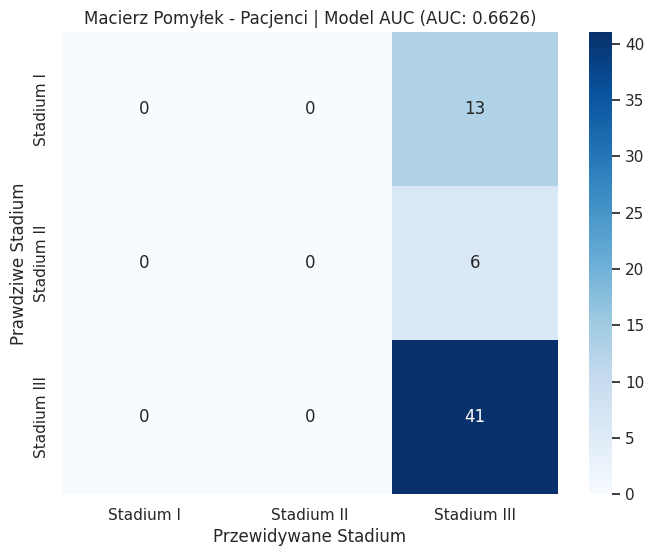

Zapisano: /content/drive/MyDrive/masked_ct_models/softvoting_AUC.png

── Soft-voting | Model F1 ──────────────────────────
PATIENT AUC: 0.6802 | Benchmark: 0.881
PATIENT ACC: 0.7333
              precision    recall  f1-score   support

   Stadium I     0.5000    0.4615    0.4800        13
  Stadium II     1.0000    0.1667    0.2857         6
 Stadium III     0.7872    0.9024    0.8409        41

    accuracy                         0.7333        60
   macro avg     0.7624    0.5102    0.5355        60
weighted avg     0.7463    0.7333    0.7072        60



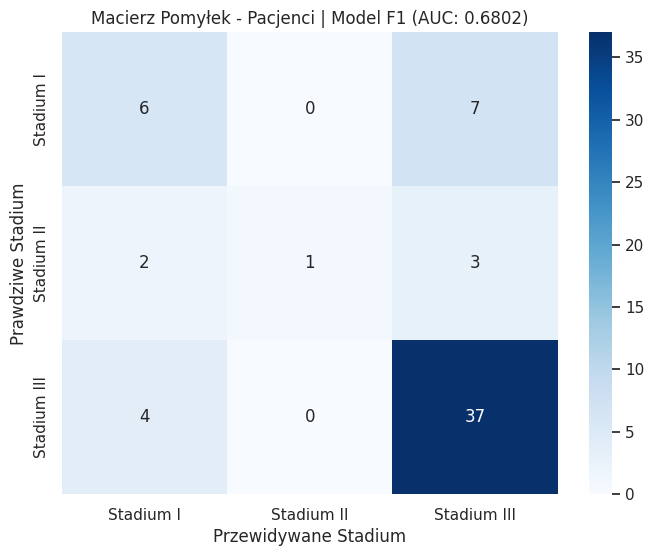

Zapisano: /content/drive/MyDrive/masked_ct_models/softvoting_F1.png

─────────────────────────────────────────────────────────────────
Fold   Model    AUC      F1       Acc      I-F1     II-F1    III-F1
─────────────────────────────────────────────────────────────────

Fold 1 — n=12 pac. (I=2, II=1, III=9)
  AUC      0.8426   0.2857   0.7500   0.0000   0.0000   0.8571
  F1       0.8920   0.8713   0.9167   0.6667   1.0000   0.9474

Fold 2 — n=12 pac. (I=3, II=1, III=8)
  AUC      0.8228   0.2667   0.6667   0.0000   0.0000   0.8000
  F1       0.7670   0.6471   0.9167   1.0000   0.0000   0.9412

Fold 3 — n=12 pac. (I=3, II=1, III=8)
  AUC      0.4296   0.2667   0.6667   0.0000   0.0000   0.8000
  F1       0.7108   0.3036   0.5000   0.2857   0.0000   0.6250

Fold 4 — n=12 pac. (I=3, II=1, III=8)
  AUC      0.4335   0.2667   0.6667   0.0000   0.0000   0.8000
  F1       0.4354   0.2667   0.6667   0.0000   0.0000   0.8000

Fold 5 — n=12 pac. (I=2, II=2, III=8)
  AUC      0.7604   0.2667   0.6

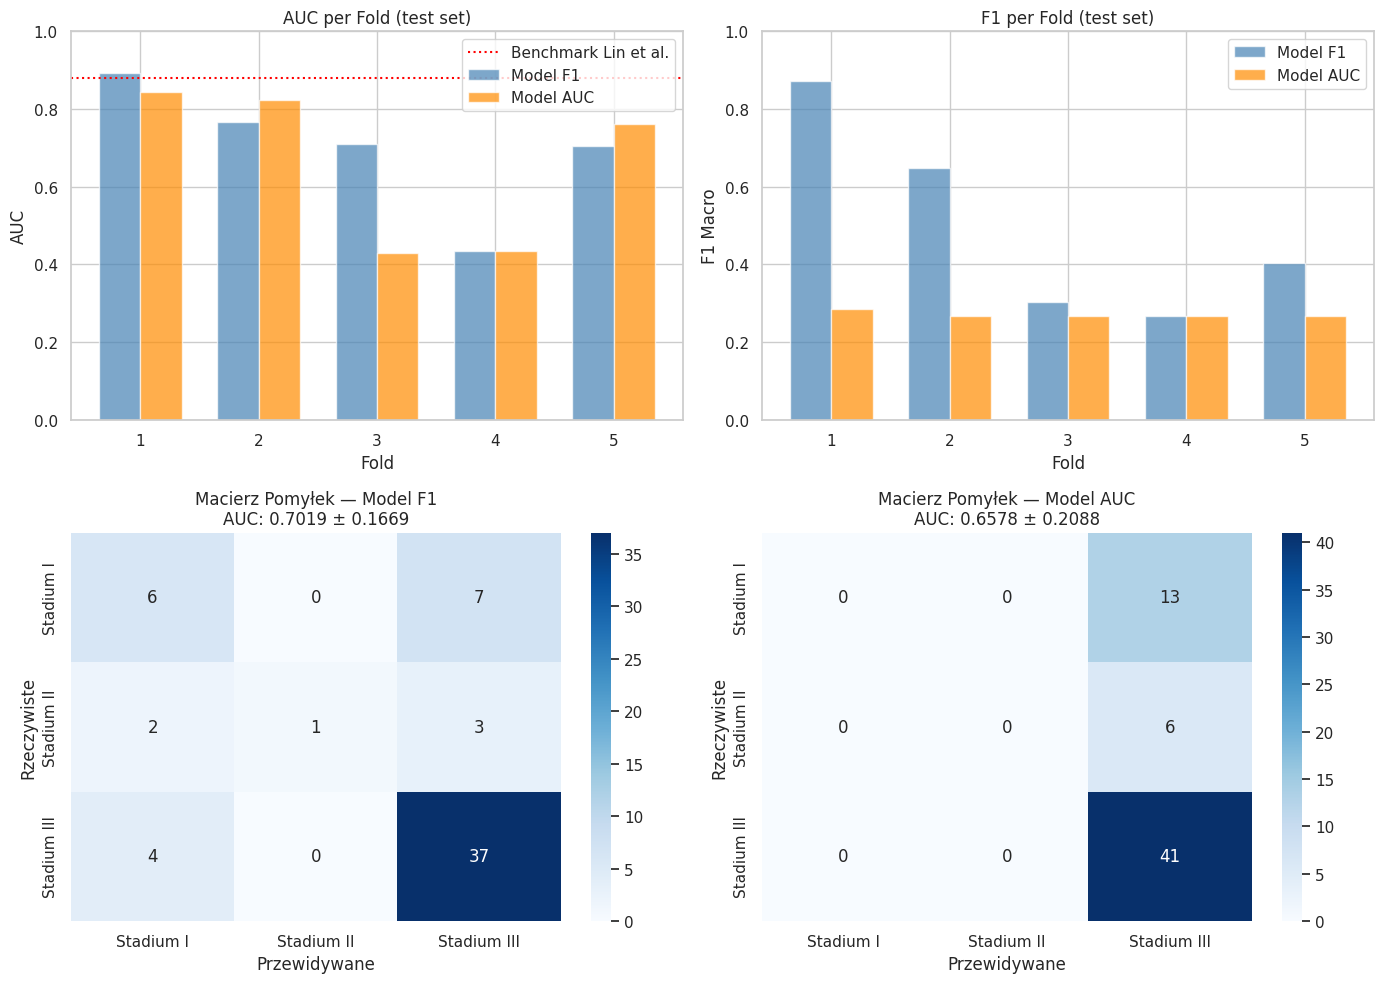

Zapisano: /content/drive/MyDrive/masked_ct_models/kfold_masked.png

Raport klasyfikacji — Model AUC:
              precision    recall  f1-score   support

   Stadium I     0.0000    0.0000    0.0000        13
  Stadium II     0.0000    0.0000    0.0000         6
 Stadium III     0.6833    1.0000    0.8119        41

    accuracy                         0.6833        60
   macro avg     0.2278    0.3333    0.2706        60
weighted avg     0.4669    0.6833    0.5548        60


Raport klasyfikacji — Model F1:
              precision    recall  f1-score   support

   Stadium I     0.5000    0.4615    0.4800        13
  Stadium II     1.0000    0.1667    0.2857         6
 Stadium III     0.7872    0.9024    0.8409        41

    accuracy                         0.7333        60
   macro avg     0.7624    0.5102    0.5355        60
weighted avg     0.7463    0.7333    0.7072        60



In [68]:
from sklearn.model_selection import StratifiedKFold

def load_model(path):
    m = ResNetHybrid(
        num_classes=3,
        dropout_rate=best_params.get('dropout_rate', 0.4)
    ).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m


DRIVE_SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

models_to_eval = {
    # 'F1':  load_model(f'{DRIVE_SAVE_DIR}/best_masked_manual_f1.pth'),
    'AUC': load_model(f'{DRIVE_SAVE_DIR}/best_masked_manual_auc.pth'),
    'F1': load_model('/content/best_hybrid_f1.pth')
}

df_test_patches = test_dataset.data_frame.copy()
df_test_patients = (
    df_test_patches
    .groupby('patient_id')['merged_label']
    .first()
    .reset_index()
)
patient_ids    = df_test_patients['patient_id'].values
patient_labels = df_test_patients['merged_label'].values

print(f"Pacjenci w test secie: {len(patient_ids)}")
print(f"Rozkład: I={np.sum(patient_labels==0)}, II={np.sum(patient_labels==1)}, III={np.sum(patient_labels==2)}")

# ── Soft-voting dla obu modeli ────────────────────────────────────────────────
def run_softvoting(model, model_name):
    model.eval()
    test_probs_raw, test_labels_raw = [], []

    with torch.no_grad():
        for inputs, clinical_data, labels in test_loader:
            inputs        = inputs.to(device)
            clinical_data = clinical_data.to(device)
            outputs       = model(inputs, clinical_data)
            probs         = torch.softmax(outputs, dim=1)
            test_probs_raw.extend(probs.cpu().numpy())
            test_labels_raw.extend(labels.cpu().numpy())

    df_test_results = test_dataset.data_frame.copy()
    df_test_results['prob_I']     = [p[0] for p in test_probs_raw]
    df_test_results['prob_II']    = [p[1] for p in test_probs_raw]
    df_test_results['prob_III']   = [p[2] for p in test_probs_raw]
    df_test_results['true_label'] = test_labels_raw

    patient_level_df = df_test_results.groupby('patient_id').agg({
        'prob_I': 'mean', 'prob_II': 'mean',
        'prob_III': 'mean', 'true_label': 'first'
    }).reset_index()

    patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
    patient_preds = np.argmax(patient_probs, axis=1)
    patient_true  = patient_level_df['true_label'].values

    patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')
    patient_acc = accuracy_score(patient_true, patient_preds)

    print(f"\n── Soft-voting | Model {model_name} ──────────────────────────")
    print(f"PATIENT AUC: {patient_auc:.4f} | Benchmark: 0.881")
    print(f"PATIENT ACC: {patient_acc:.4f}")
    print(classification_report(patient_true, patient_preds,
                                target_names=target_names, digits=4, zero_division=0))

    cm = confusion_matrix(patient_true, patient_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Macierz Pomyłek - Pacjenci | Model {model_name} (AUC: {patient_auc:.4f})')
    plt.ylabel('Prawdziwe Stadium')
    plt.xlabel('Przewidywane Stadium')
    save_path = f'{DRIVE_SAVE_DIR}/softvoting_{model_name}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {save_path}")

    return patient_auc, patient_acc, patient_true, patient_probs

for name, m in models_to_eval.items():
    run_softvoting(m, name)


    def evaluate_fold(model, df_fold):
        fold_dataset = LungCancerHybridDataset.__new__(LungCancerHybridDataset)
        fold_dataset.data_frame = df_fold.reset_index(drop=True)
        fold_dataset.root_dir   = IMG_DIR_COLAB
        fold_dataset.transform  = val_test_transforms

        fold_loader = DataLoader(fold_dataset, batch_size=32, shuffle=False, num_workers=2)

        fold_labels, fold_probs = [], []
        with torch.no_grad():
            for inputs, clinical, labels in fold_loader:
                inputs   = inputs.to(device)
                clinical = clinical.to(device)
                outputs  = model(inputs, clinical)
                probs    = torch.softmax(outputs, dim=1)
                fold_labels.extend(labels.cpu().numpy())
                fold_probs.extend(probs.cpu().numpy())

        df_fold = df_fold.copy()
        df_fold['prob_I']     = [p[0] for p in fold_probs]
        df_fold['prob_II']    = [p[1] for p in fold_probs]
        df_fold['prob_III']   = [p[2] for p in fold_probs]
        df_fold['true_label'] = fold_labels

        patient_agg = (
            df_fold.groupby('patient_id')[['prob_I', 'prob_II', 'prob_III', 'true_label']]
            .agg({'prob_I': 'mean', 'prob_II': 'mean',
                  'prob_III': 'mean', 'true_label': 'first'})
            .reset_index()
        )

        probs_arr = patient_agg[['prob_I', 'prob_II', 'prob_III']].values
        preds_arr = np.argmax(probs_arr, axis=1)
        true_arr  = patient_agg['true_label'].values

        if len(np.unique(true_arr)) < 2:
            return None

        try:
            fold_auc = roc_auc_score(true_arr, probs_arr, multi_class='ovr',
                                      average='macro', labels=[0, 1, 2])
        except ValueError:
            fold_auc = float('nan')

        fold_f1      = f1_score(true_arr, preds_arr, average='macro', labels=[0,1,2], zero_division=0)
        fold_acc     = accuracy_score(true_arr, preds_arr)
        per_class_f1 = f1_score(true_arr, preds_arr, average=None, labels=[0,1,2], zero_division=0)

        return {
            'auc':    fold_auc,  'f1':    fold_f1,   'acc':    fold_acc,
            'f1_I':   per_class_f1[0], 'f1_II': per_class_f1[1], 'f1_III': per_class_f1[2],
            'n_I':    int(np.sum(true_arr == 0)), 'n_II': int(np.sum(true_arr == 1)),
            'n_III':  int(np.sum(true_arr == 2)), 'true': true_arr, 'probs': probs_arr,
        }

# ── K-Fold na test secie ──────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_results = {name: [] for name in models_to_eval}
all_true    = {name: [] for name in models_to_eval}
all_probs   = {name: [] for name in models_to_eval}

print(f"\n{'─'*65}")
print(f"{'Fold':<6} {'Model':<8} {'AUC':<8} {'F1':<8} {'Acc':<8} {'I-F1':<8} {'II-F1':<8} {'III-F1'}")
print(f"{'─'*65}")

for fold, (_, test_idx) in enumerate(skf.split(patient_ids, patient_labels)):
    test_patients = set(patient_ids[test_idx])
    df_fold = df_test_patches[df_test_patches['patient_id'].isin(test_patients)].copy()

    n_I   = np.sum(patient_labels[test_idx] == 0)
    n_II  = np.sum(patient_labels[test_idx] == 1)
    n_III = np.sum(patient_labels[test_idx] == 2)
    print(f"\nFold {fold+1} — n={len(test_patients)} pac. (I={n_I}, II={n_II}, III={n_III})")

    for name, model in models_to_eval.items():
        res = evaluate_fold(model, df_fold)
        if res is None:
            print(f"  {name:<8} POMINIĘTY — za mało klas")
            continue
        res['fold'] = fold + 1
        all_results[name].append(res)
        all_true[name].extend(res['true'])
        all_probs[name].extend(res['probs'])
        print(f"  {name:<8} {res['auc']:<8.4f} {res['f1']:<8.4f} "
              f"{res['acc']:<8.4f} {res['f1_I']:<8.4f} "
              f"{res['f1_II']:<8.4f} {res['f1_III']:.4f}")

print(f"\n{'═'*65}")
print("PODSUMOWANIE K-FOLD (Patient Level) — ocena stabilności")
print(f"{'═'*65}")

for name in models_to_eval:
    if not all_results[name]:
        continue
    df_res = pd.DataFrame(all_results[name])
    print(f"\nModel {name}:")
    for metric in ['auc', 'f1', 'acc', 'f1_I', 'f1_II', 'f1_III']:
        vals = df_res[metric].dropna()
        print(f"  {metric.upper():<10}: {vals.mean():.4f} ± {vals.std():.4f}")

print(f"\n{'─'*65}")
print("WYNIK REFERENCYJNY — pełny test set:")
for name, model in models_to_eval.items():
    res_full = evaluate_fold(model, df_test_patches)
    if res_full:
        print(f"  Model {name}: AUC={res_full['auc']:.4f} | F1={res_full['f1']:.4f} | Acc={res_full['acc']:.4f}")

# ── Wizualizacje K-Fold ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'F1': 'steelblue', 'AUC': 'darkorange'}
x = np.arange(1, 6)
width = 0.35

ax = axes[0, 0]
for i, (name, color) in enumerate(colors.items()):
    aucs = [r['auc'] for r in all_results[name]]
    ax.bar(x + i * width - width/2, aucs, width, color=color, alpha=0.7, label=f'Model {name}')
ax.axhline(0.881, color='red', linestyle=':', label='Benchmark Lin et al.')
ax.set_xlabel('Fold')
ax.set_ylabel('AUC')
ax.set_title('AUC per Fold (test set)')
ax.set_xticks(x)
ax.legend()
ax.set_ylim(0, 1)

ax = axes[0, 1]
for i, (name, color) in enumerate(colors.items()):
    f1s = [r['f1'] for r in all_results[name]]
    ax.bar(x + i * width - width/2, f1s, width, color=color, alpha=0.7, label=f'Model {name}')
ax.set_xlabel('Fold')
ax.set_ylabel('F1 Macro')
ax.set_title('F1 per Fold (test set)')
ax.set_xticks(x)
ax.legend()
ax.set_ylim(0, 1)

for col, name in enumerate(['F1', 'AUC']):
    ax = axes[1, col]
    if not all_true[name]:
        ax.set_visible(False)
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)
    cm = confusion_matrix(true_arr, preds_arr, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Przewidywane')
    ax.set_ylabel('Rzeczywiste')
    mean_auc = pd.DataFrame(all_results[name])['auc'].mean()
    std_auc  = pd.DataFrame(all_results[name])['auc'].std()
    ax.set_title(f'Macierz Pomyłek — Model {name}\nAUC: {mean_auc:.4f} ± {std_auc:.4f}')

plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/kfold_masked.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Zapisano: {save_path}")

for name in models_to_eval:
    if not all_true[name]:
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)
    print(f"\nRaport klasyfikacji — Model {name}:")
    print(classification_report(true_arr, preds_arr,
                                target_names=target_names, digits=4, zero_division=0))

Wykresy dla zbioru TRAIN i VAL

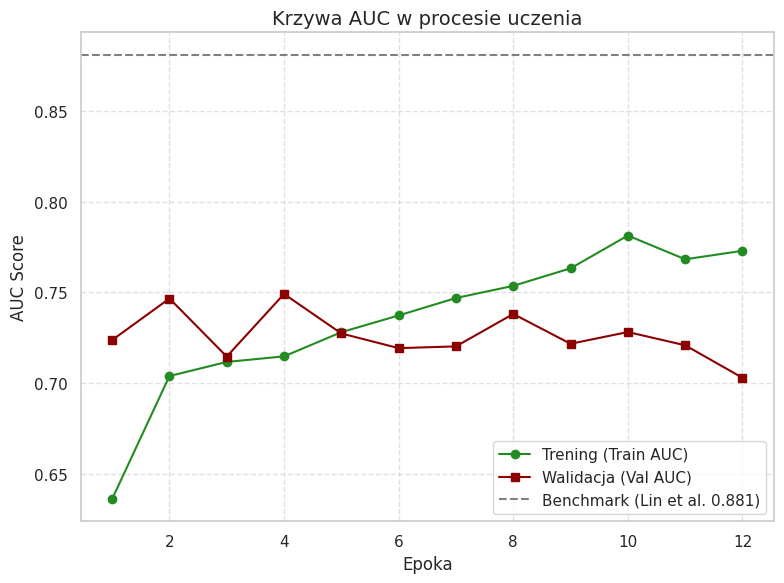

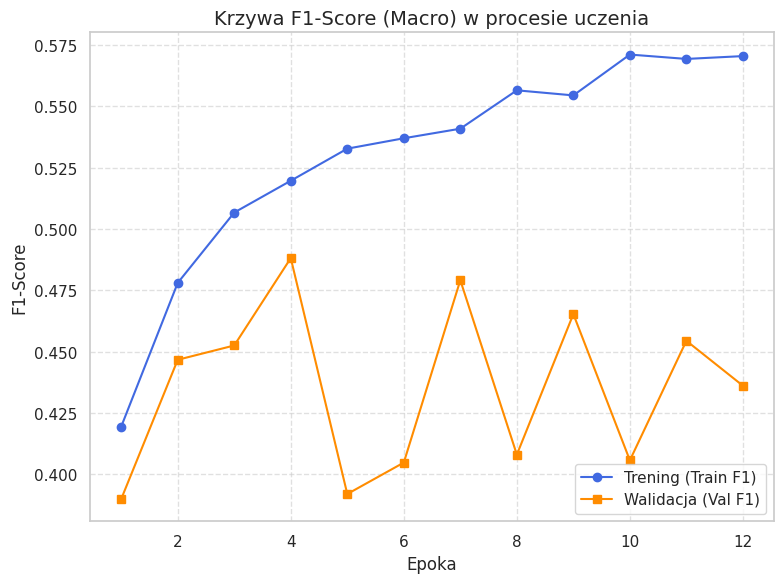

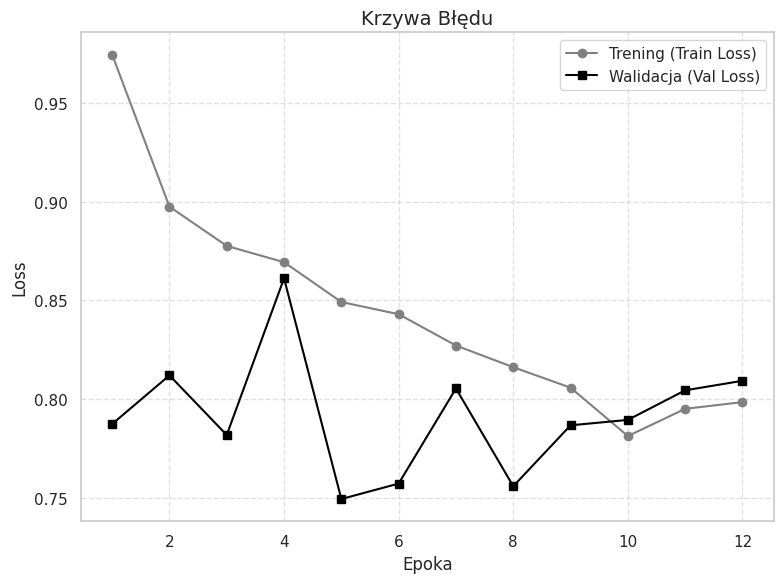

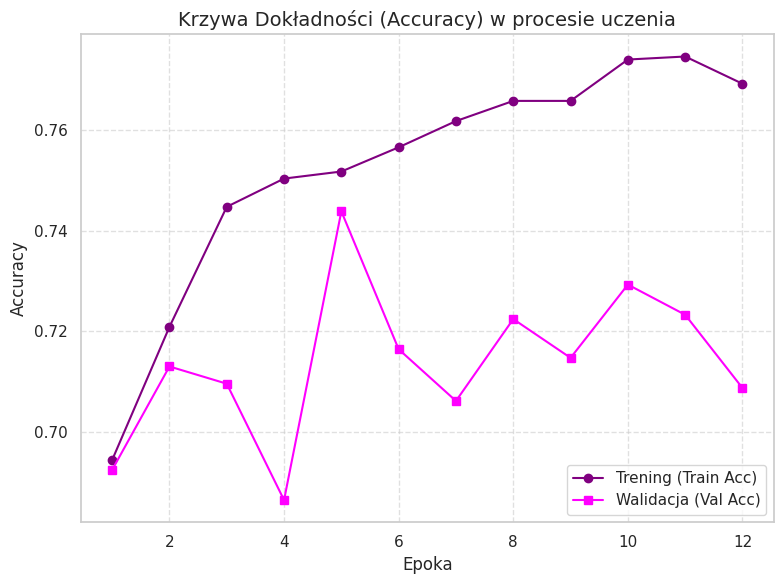

In [45]:
epochs_range = range(1, len(history['train_loss']) + 1)

# AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_auc'], label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history['val_auc'], label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/masked_ct_models/final_hybrid_auc_masked_manual.png', dpi=300, bbox_inches='tight')
plt.show()

# F1-Score
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro) w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/masked_ct_models/final_hybrid_f1_masked_manual.png', dpi=300, bbox_inches='tight')
plt.show()

# Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_loss'], label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history['val_loss'], label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/masked_ct_models/final_hybrid_loss_masked_manual.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_acc'], label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history['val_acc'], label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy) w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/masked_ct_models/final_hybrid_accuracy_masked_manual.png', dpi=300, bbox_inches='tight')
plt.show()

Krzywe ROC

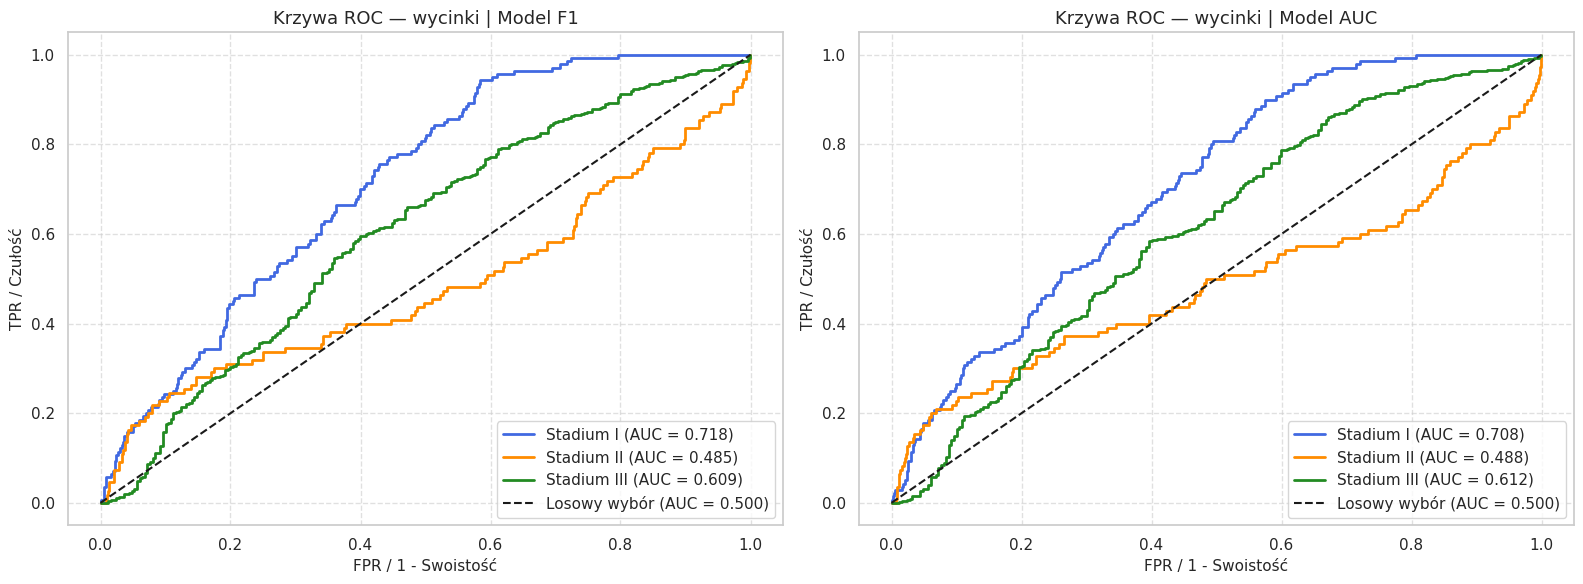

Zapisano: /content/drive/MyDrive/masked_ct_models/roc_slices_both_manual.png


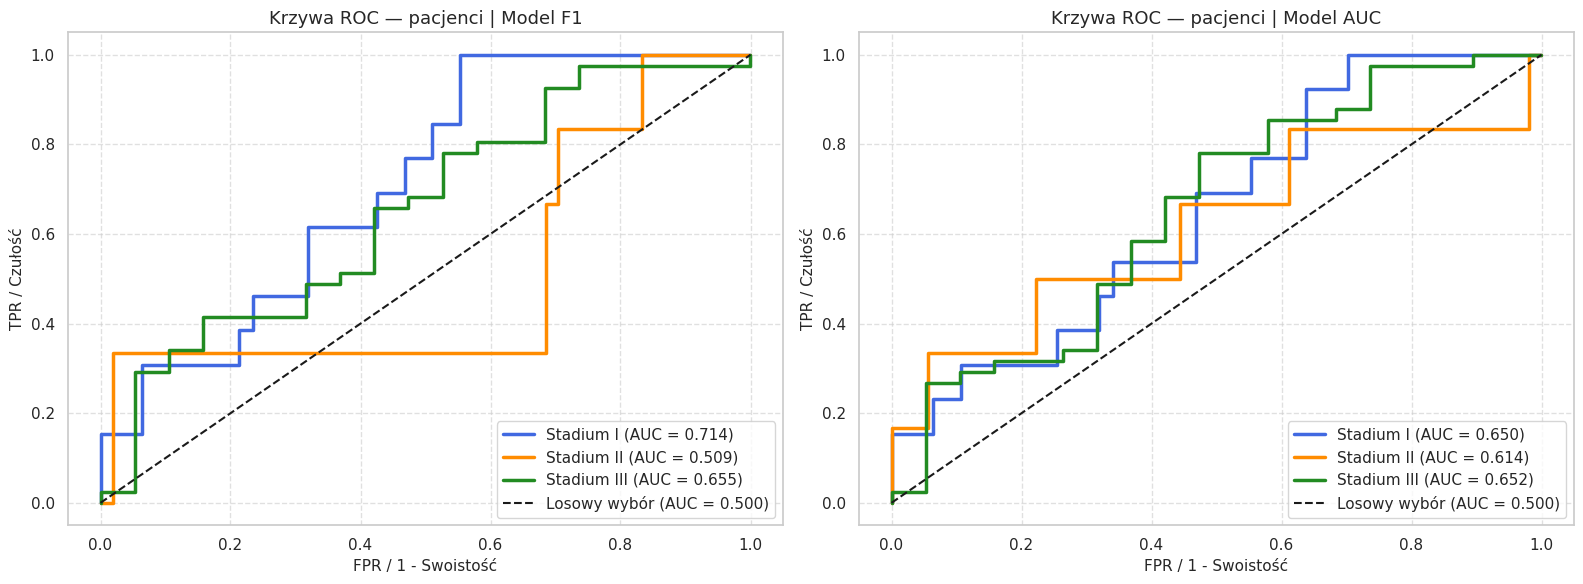

Zapisano: /content/drive/MyDrive/masked_ct_models/roc_patients_both_manual.png


In [61]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
classes      = [0, 1, 2]
colors       = ['royalblue', 'darkorange', 'forestgreen']
DRIVE_SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'

def get_top_k_mean(group, k=7):
    pk_I   = group['prob_I'].nlargest(k).mean()
    pk_II  = group['prob_II'].nlargest(k).mean()
    pk_III = group['prob_III'].nlargest(k).mean()
    total  = pk_I + pk_II + pk_III
    return pd.Series({
        'final_prob_I':   pk_I / total,
        'final_prob_II':  pk_II / total,
        'final_prob_III': pk_III / total,
        'true_label':     group['true_label'].iloc[0]
    })

def get_predictions(model):
    model.eval()
    test_labels, test_probs = [], []
    with torch.no_grad():
        for inputs, clinical, labels in test_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            outputs  = model(inputs, clinical)
            probs    = torch.softmax(outputs, dim=1)
            test_labels.extend(labels.cpu().numpy())
            test_probs.extend(probs.cpu().numpy())
    return np.array(test_labels), np.array(test_probs)

def get_patient_probs(test_labels, test_probs):
    df_test = test_dataset.data_frame.copy()
    df_test['prob_I']     = test_probs[:, 0]
    df_test['prob_II']    = test_probs[:, 1]
    df_test['prob_III']   = test_probs[:, 2]
    df_test['true_label'] = test_labels

    patient_level_df = df_test.groupby('patient_id').apply(
        get_top_k_mean, include_groups=False
    ).reset_index()

    patient_probs_arr = patient_level_df[['final_prob_I', 'final_prob_II', 'final_prob_III']].values
    patient_true      = patient_level_df['true_label'].values
    return patient_true, patient_probs_arr

# Pobierz predykcje dla obu modeli
predictions = {}
for name, model in models_to_eval.items():
    test_labels, test_probs = get_predictions(model)
    patient_true, patient_probs = get_patient_probs(test_labels, test_probs)
    predictions[name] = {
        'test_labels':    test_labels,
        'test_probs':     test_probs,
        'patient_true':   patient_true,
        'patient_probs':  patient_probs,
    }

# ── Krzywe ROC — poziom wycinków ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, data) in zip(axes, predictions.items()):
    y_bin = label_binarize(data['test_labels'], classes=classes)
    for i, (cls_name, color) in enumerate(zip(target_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], data['test_probs'][:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy wybór (AUC = 0.500)')
    ax.set_xlabel('FPR / 1 - Swoistość', fontsize=11)
    ax.set_ylabel('TPR / Czułość', fontsize=11)
    ax.set_title(f'Krzywa ROC — wycinki | Model {name}', fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/roc_slices_both_manual.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {save_path}")

# ── Krzywe ROC — poziom pacjentów ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, data) in zip(axes, predictions.items()):
    y_bin = label_binarize(data['patient_true'], classes=classes)
    for i, (cls_name, color) in enumerate(zip(target_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], data['patient_probs'][:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{cls_name} (AUC = {roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy wybór (AUC = 0.500)')
    ax.set_xlabel('FPR / 1 - Swoistość', fontsize=11)
    ax.set_ylabel('TPR / Czułość', fontsize=11)
    ax.set_title(f'Krzywa ROC — pacjenci | Model {name}', fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/roc_patients_both_manual.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {save_path}")

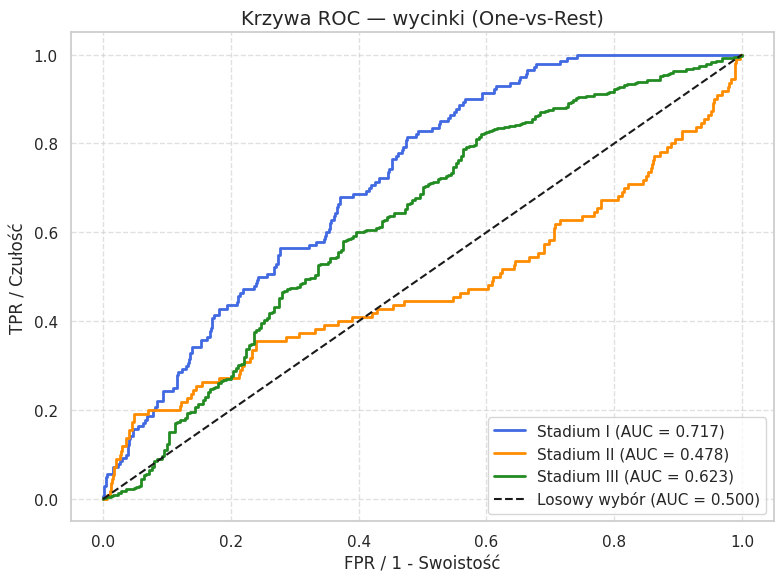

Zapisano: /content/drive/MyDrive/masked_ct_models/roc_slices_manual.png


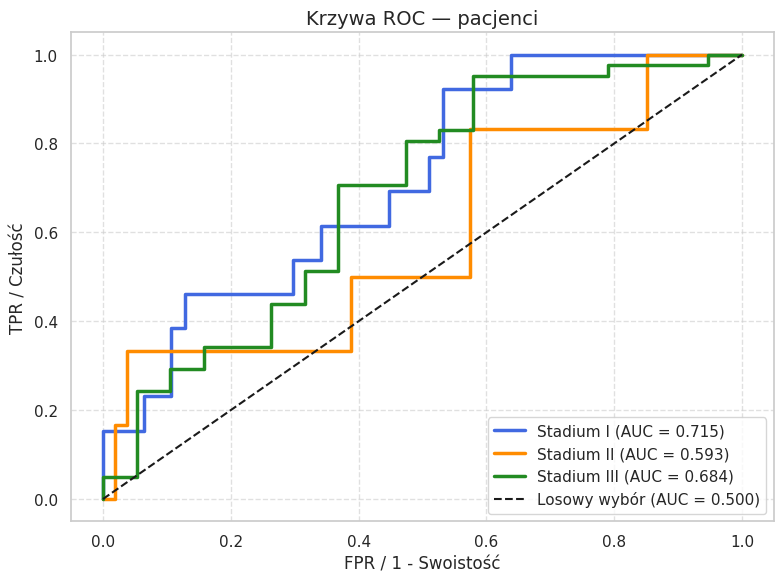

Zapisano: /content/drive/MyDrive/masked_ct_models/roc_patients_manual.png


In [70]:
model_single = load_model('/content/best_hybrid_f1.pth')
model_single.eval()

test_labels, test_probs = get_predictions(model_single)
patient_true, patient_probs = get_patient_probs(test_labels, test_probs)

plot_colors = ['royalblue', 'darkorange', 'forestgreen']

# ── Krzywa ROC — poziom wycinków ─────────────────────────────────────────────
y_bin = label_binarize(test_labels, classes=classes)
plt.figure(figsize=(8, 6))
for i, (cls_name, color) in enumerate(zip(target_names, plot_colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy wybór (AUC = 0.500)')
plt.xlabel('FPR / 1 - Swoistość', fontsize=12)
plt.ylabel('TPR / Czułość', fontsize=12)
plt.title('Krzywa ROC — wycinki (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/roc_slices_manual.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Zapisano: {save_path}")

# ── Krzywa ROC — poziom pacjentów ────────────────────────────────────────────
y_bin_patient = label_binarize(patient_true, classes=classes)
plt.figure(figsize=(8, 6))
for i, (cls_name, color) in enumerate(zip(target_names, plot_colors)):
    fpr, tpr, _ = roc_curve(y_bin_patient[:, i], patient_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{cls_name} (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy wybór (AUC = 0.500)')
plt.xlabel('FPR / 1 - Swoistość', fontsize=12)
plt.ylabel('TPR / Czułość', fontsize=12)
plt.title('Krzywa ROC — pacjenci', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_path = f'{DRIVE_SAVE_DIR}/roc_patients_manual.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Zapisano: {save_path}")

Grad-cam

Znaleziono przykłady dla klas: [1, 2, 0]


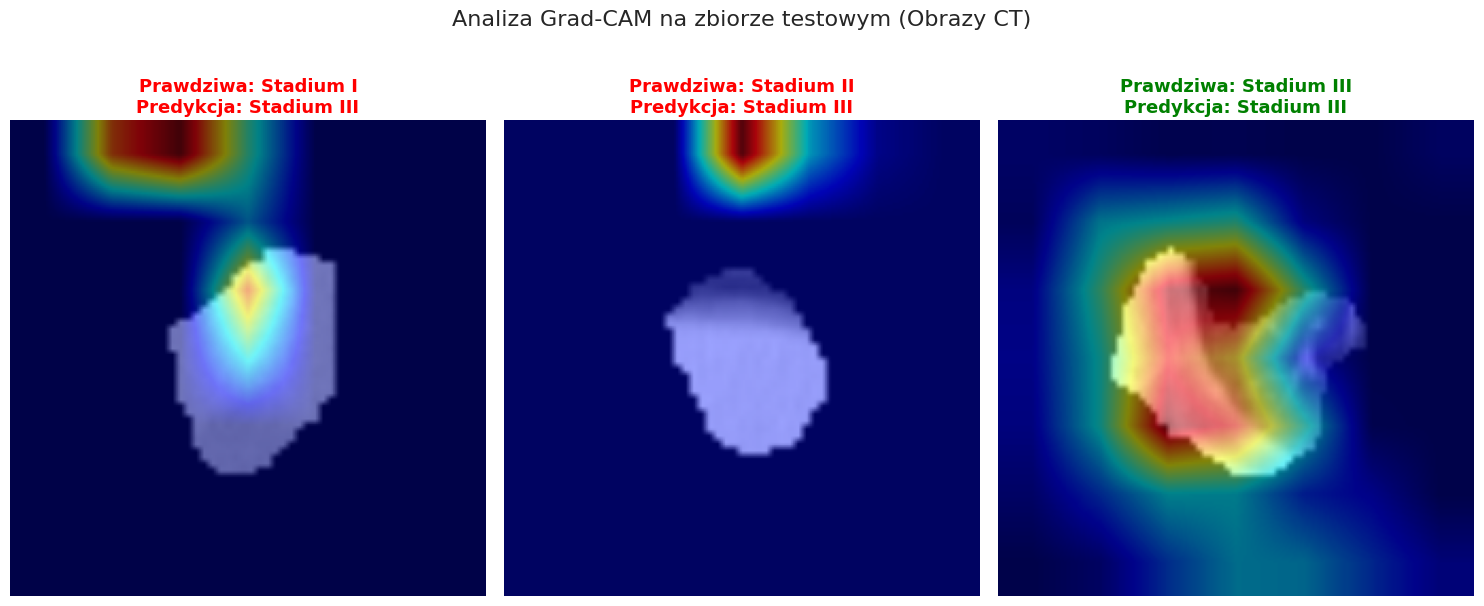

In [47]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


class HybridModelWrapper(torch.nn.Module):
    def __init__(self, model, clinical_data):
        super(HybridModelWrapper, self).__init__()
        self.model = model
        self.clinical_data = clinical_data

    def forward(self, x):
        return self.model(x, self.clinical_data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

target_layers = [model.backbone.layer4[-1]]
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

# --- NOWY FRAGMENT: Pobieranie po jednym przykładzie dla każdej klasy ---
examples = {}

# Upewnij się, że używasz odpowiedniego loadera (np. test_loader lub val_loader)
for inputs, clinical, labels in val_loader: # ZMIEŃ na test_loader, jeśli masz
    for i in range(len(labels)):
        class_idx = labels[i].item()

        # Jeśli jeszcze nie mamy przykładu dla tej klasy, zapisujemy go
        if class_idx not in examples:
            examples[class_idx] = (inputs[i].detach(), clinical[i].detach())

        # Przerywamy, gdy mamy już po jednym przykładzie dla wszystkich 3 klas (0, 1, 2)
        if len(examples) == 3:
            break
    if len(examples) == 3:
        break

print(f"Znaleziono przykłady dla klas: {list(examples.keys())}")
# -------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Analiza Grad-CAM na zbiorze testowym (Obrazy CT)', fontsize=16, y=1.05)

for class_idx in range(3):
    img_tensor, clin_tensor = examples[class_idx]

    img_tensor = img_tensor.unsqueeze(0).to(device)
    clin_tensor = clin_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor, clin_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()

    wrapped_model = HybridModelWrapper(model, clin_tensor)

    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    targets = [ClassifierOutputTarget(class_idx)]

    # Generowanie mapy ciepła
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min()) # Skalowanie 0-1

    # Nałożenie mapy ciepła na oryginalny obraz
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax = axes[class_idx]
    ax.imshow(cam_image)

    # Zmiana koloru tytułu: Zielony jeśli trafił, Czerwony jeśli się pomylił
    color = 'green' if class_idx == pred_idx else 'red'

    ax.set_title(f"Prawdziwa: {target_names[class_idx]}\nPredykcja: {target_names[pred_idx]}",
                 fontsize=13, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/final_hybrid_gradcam_test_dual_manual.png', dpi=300, bbox_inches='tight')
plt.show()

Kalibracja progów


KALIBRACJA PROGÓW — Model F1
Kalibracja progów na zbiorze walidacyjnym...
Optymalne progi:
  Stadium I:   0.80
  Stadium II:  0.85
  Stadium III: 1.00 (Baza)

--- PRZED TUNINGIEM ---
              precision    recall  f1-score   support

   Stadium I       0.42      0.38      0.40        13
  Stadium II       0.50      0.17      0.25         6
 Stadium III       0.74      0.83      0.78        41

    accuracy                           0.67        60
   macro avg       0.55      0.46      0.48        60
weighted avg       0.65      0.67      0.65        60

--- PO TUNINGU ---
              precision    recall  f1-score   support

   Stadium I       0.32      0.54      0.40        13
  Stadium II       0.50      0.17      0.25         6
 Stadium III       0.78      0.68      0.73        41

    accuracy                           0.60        60
   macro avg       0.53      0.46      0.46        60
weighted avg       0.65      0.60      0.61        60



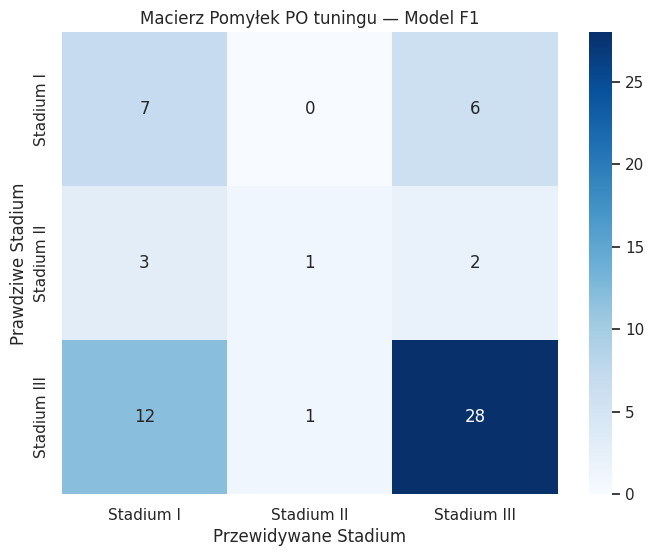

Zapisano: /content/drive/MyDrive/masked_ct_models/calibration_F1_tr12.png

KALIBRACJA PROGÓW — Model AUC
Kalibracja progów na zbiorze walidacyjnym...
Optymalne progi:
  Stadium I:   0.25
  Stadium II:  0.30
  Stadium III: 1.00 (Baza)

--- PRZED TUNINGIEM ---
              precision    recall  f1-score   support

   Stadium I       0.00      0.00      0.00        13
  Stadium II       0.00      0.00      0.00         6
 Stadium III       0.68      1.00      0.81        41

    accuracy                           0.68        60
   macro avg       0.23      0.33      0.27        60
weighted avg       0.47      0.68      0.55        60

--- PO TUNINGU ---
              precision    recall  f1-score   support

   Stadium I       0.35      0.62      0.44        13
  Stadium II       0.40      0.33      0.36         6
 Stadium III       0.78      0.61      0.68        41

    accuracy                           0.58        60
   macro avg       0.51      0.52      0.50        60
weighted avg   

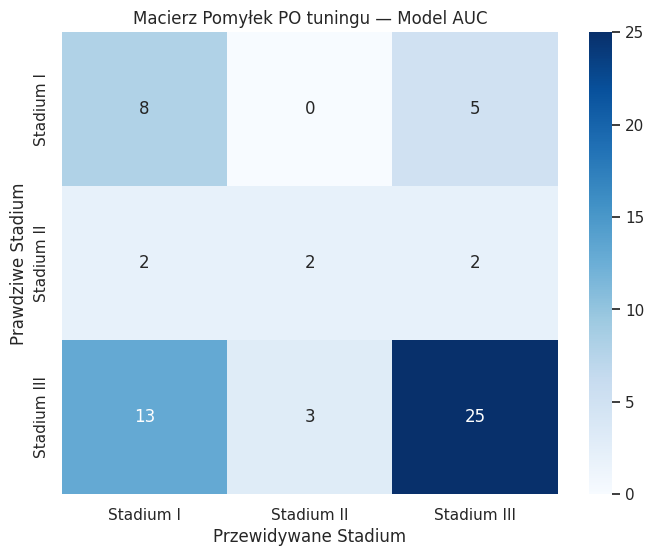

Zapisano: /content/drive/MyDrive/masked_ct_models/calibration_AUC_tr12.png

KALIBRACJA PROGÓW — Model MAN
Kalibracja progów na zbiorze walidacyjnym...
Optymalne progi:
  Stadium I:   0.75
  Stadium II:  0.70
  Stadium III: 1.00 (Baza)

--- PRZED TUNINGIEM ---
              precision    recall  f1-score   support

   Stadium I       0.50      0.46      0.48        13
  Stadium II       1.00      0.17      0.29         6
 Stadium III       0.79      0.90      0.84        41

    accuracy                           0.73        60
   macro avg       0.76      0.51      0.54        60
weighted avg       0.75      0.73      0.71        60

--- PO TUNINGU ---
              precision    recall  f1-score   support

   Stadium I       0.38      0.62      0.47        13
  Stadium II       0.50      0.17      0.25         6
 Stadium III       0.81      0.73      0.77        41

    accuracy                           0.65        60
   macro avg       0.56      0.50      0.50        60
weighted avg  

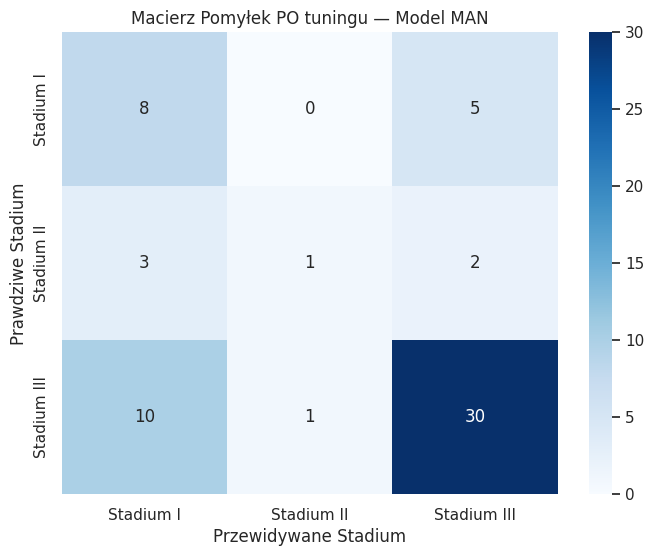

Zapisano: /content/drive/MyDrive/masked_ct_models/calibration_MAN_tr12.png


In [63]:
def calibrate_thresholds(model, model_name):
    print(f"\n{'='*60}")
    print(f"KALIBRACJA PROGÓW — Model {model_name}")
    print(f"{'='*60}")

    # Predykcje na zbiorze walidacyjnym
    df_val_patches = val_dataset.data_frame.copy()
    val_results    = evaluate_fold(model, df_val_patches)
    val_probs      = val_results['probs']
    val_true       = val_results['true']

    # Predykcje na zbiorze testowym
    test_results = evaluate_fold(model, df_test_patches)
    test_probs   = test_results['probs']
    test_true    = test_results['true']

    # Kalibracja na zbiorze walidacyjnym
    best_f1         = 0.0
    best_thresholds = [1.0, 1.0, 1.0]
    thresholds_range = np.arange(0.1, 1.05, 0.05)

    print("Kalibracja progów na zbiorze walidacyjnym...")
    for t0 in thresholds_range:
        for t1 in thresholds_range:
            current_thresholds = np.array([t0, t1, 1.0])
            adjusted_probs     = val_probs / current_thresholds
            preds              = np.argmax(adjusted_probs, axis=1)
            f1                 = f1_score(val_true, preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1         = f1
                best_thresholds = current_thresholds

    print(f"Optymalne progi:")
    print(f"  Stadium I:   {best_thresholds[0]:.2f}")
    print(f"  Stadium II:  {best_thresholds[1]:.2f}")
    print(f"  Stadium III: {best_thresholds[2]:.2f} (Baza)")

    # Ewaluacja na test secie
    base_preds     = np.argmax(test_probs, axis=1)
    adjusted_probs = test_probs / best_thresholds
    tuned_preds    = np.argmax(adjusted_probs, axis=1)

    print(f"\n--- PRZED TUNINGIEM ---")
    print(classification_report(test_true, base_preds,
                                target_names=target_names, zero_division=0))

    print(f"--- PO TUNINGU ---")
    print(classification_report(test_true, tuned_preds,
                                target_names=target_names, zero_division=0))

    cm = confusion_matrix(test_true, tuned_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Macierz Pomyłek PO tuningu — Model {model_name}')
    plt.ylabel('Prawdziwe Stadium')
    plt.xlabel('Przewidywane Stadium')
    save_path = f'{DRIVE_SAVE_DIR}/calibration_{model_name}_tr12.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {save_path}")

    return best_thresholds, test_true, base_preds, tuned_preds

for name, model in models_to_eval.items():
    calibrate_thresholds(model, name)